In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wind-turbine/Wind-Turbine-SCADA-signals-2017_0.xlsx
/kaggle/input/wind-turbine/Train.csv
/kaggle/input/wind-turbine/Test.csv


# Title: Predictive Maintenance for Wind Turbines using Machine Learning

##  Description of the Project
The U.S. Department of Energy has released a guide on predictive maintenance procedures for wind energy, a cutting-edge renewable energy source. This method evaluates and predicts component deterioration using sensor data and analytical approaches. By accurately anticipating failure trends, operating and maintenance costs can be significantly reduced, allowing for the replacement of components before they fail. The study involves training and evaluating different machine learning algorithms to predict breakdowns in wind turbines.

## Goal
This project uses machine learning to improve wind energy production by collecting data on generator failures. The dataset consists of 40 predictors, with 20,000 observations in the training set and 5,000 observations in the test set. The goal is to build classification models to proactively repair generators and minimize maintenance costs. The model interprets predictions as true positives (TP), true negative (TN),  false negatives (FN), and false positives (FP). The model shows that fixing generators is less expensive than replacing them and inspecting them.

## Description of the Data

The data is partitioned into two sets: the train set and the test set. The train set contains 20,000 rows and 41 columns, while the test set contains 5,000 rows and 41 columns. The data set consists of 40 predictor variables and 1 target variable. The target variable consists of two distinct values, 0 and 1, which represent non-failure and failure, respectively. The training data for the target variable exhibited the following distribution. There are a total of 18,890 machines in good condition, and a total of 1,110 machines that have failed and require repair before breaking down. The distribution of the test data for the target variable is as follows: There are a total of 4718 machines in good condition. Out of them, there are 282 machines that have experienced failures and require repairs to prevent them from breaking down.

The data presented is a modified version of the original sensor-gathered data.
The Train.csv file is intended for the purpose of training and fine-tuning models. 
- The Test.csv file should only be utilised for evaluating the performance of the final best model.
- Both datasets contain 40 predictor variables and 1 target variable.

Data Source: https://www.kaggle.com/datasets/mariyamalshatta/renewind/data.

# Importing Libraries

In [2]:
## libraries for reading and manipulating data
import pandas as pd
import numpy as np

## libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## libraries for splitting data
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

## libraries for imbalance dataset
from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler

## libraries for computing accuracy score
from sklearn.metrics import (make_scorer,f1_score, accuracy_score, recall_score, precision_score,
                            confusion_matrix, roc_auc_score)

## library for data scaling
from sklearn.preprocessing import StandardScaler

## library for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV


## model building 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ( AdaBoostClassifier, GradientBoostingClassifier, 
                              RandomForestClassifier, BaggingClassifier
)
from xgboost import XGBClassifier

## suppress warnings 
import warnings
warnings.filterwarnings("ignore")

## Loading Data

In [3]:
## loading dataset with pandas
train_generator_data = pd.read_csv("/kaggle/input/wind-turbine/Train.csv")
test_generator_data = pd.read_csv("/kaggle/input/wind-turbine/Test.csv")

In [4]:
## creating a copy of the data
df_train = train_generator_data.copy()
df_test= test_generator_data.copy()

## Data Overview

In [5]:
## lets preview our train data
df_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [6]:
## lets preview our test data
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


## Understanding The Dataset

In [7]:
## lets the check the number of cols and rows for train data
print(f"Total Number Of Rows: {df_train.shape[0]} -> Total Number Of Cols: {df_train.shape[1]}")

Total Number Of Rows: 20000 -> Total Number Of Cols: 41


In [8]:
## lets the check the number of cols and rows for train data
print(f"Total Number Of Rows: {df_test.shape[0]} -> Total Number Of Cols: {df_test.shape[1]}")

Total Number Of Rows: 5000 -> Total Number Of Cols: 41


In [9]:
## findng a summary description of the train data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [10]:
## findng a summary description of the test data
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

In [11]:
## lets check the number of duplicates in the train data
df_train.duplicated().sum()

0

In [12]:
## lets check the number of duplicates in the test data
df_test.duplicated().sum()

0

In [13]:
## lets check for missing values in the train data
df_train.isnull().sum()

V1        18
V2        18
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
V10        0
V11        0
V12        0
V13        0
V14        0
V15        0
V16        0
V17        0
V18        0
V19        0
V20        0
V21        0
V22        0
V23        0
V24        0
V25        0
V26        0
V27        0
V28        0
V29        0
V30        0
V31        0
V32        0
V33        0
V34        0
V35        0
V36        0
V37        0
V38        0
V39        0
V40        0
Target     0
dtype: int64

In [14]:
## lets check for missing values in the test data
df_test.isnull().sum()

V1        5
V2        6
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64

### Observations 
- There are 20,000 rows in the training set and 5000 rows in the rest with 41 columns 
- Not much information from the data, since the data is encrypted. 
- The columns V1 and V2 have missings values from both the training and test dataset. 
- There are no duplicate values

## Exploratory Data Analysis

### Target Variable Analysis For Train Dataset

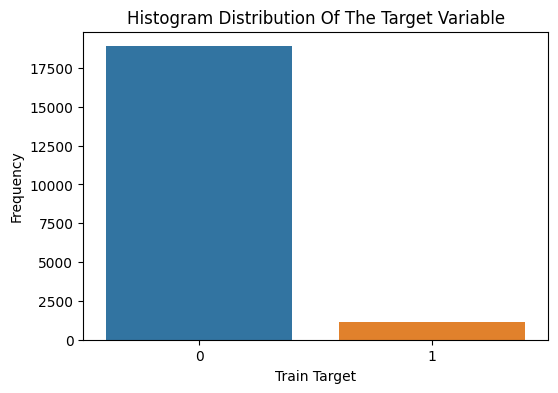

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_train, x="Target")

plt.title('Histogram Distribution Of The Target Variable')
plt.xlabel('Train Target')
plt.ylabel('Frequency')

plt.show()

The insight gathered from the figure shows that the data is inbalance. Meaning having more 0s than 1s.

In [16]:
## lets get the counts for each class of the target variable
df_train['Target'].value_counts()

Target
0    18890
1     1110
Name: count, dtype: int64

## Test Data Target Variable Analysis

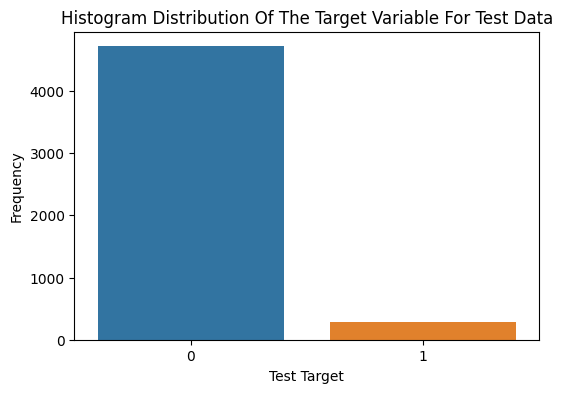

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_test, x="Target")
plt.title('Histogram Distribution Of The Target Variable For Test Data')
plt.xlabel('Test Target')
plt.ylabel('Frequency')

plt.show()

In [18]:
## lets get the counts for each class of the target variable
df_test['Target'].value_counts()

Target
0    4718
1     282
Name: count, dtype: int64

### Observations: 
- The data from the Target column is imbalance.

## Descriptive Analysis
This involves summarizing and understanding the main features of a dataset. This type of analysis provides insights into the data's distribution, central tendency, variability, and relationships between variables

In [19]:
## computing the summary statistics on train data
df_train.describe().round().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.0,3.0,-12.0,-3.0,-1.0,2.0,15.0
V2,19982.0,0.0,3.0,-12.0,-2.0,0.0,3.0,13.0
V3,20000.0,2.0,3.0,-11.0,0.0,2.0,5.0,17.0
V4,20000.0,-0.0,3.0,-15.0,-2.0,-0.0,2.0,13.0
V5,20000.0,-0.0,2.0,-9.0,-2.0,-0.0,1.0,8.0
V6,20000.0,-1.0,2.0,-10.0,-2.0,-1.0,0.0,7.0
V7,20000.0,-1.0,2.0,-8.0,-2.0,-1.0,0.0,8.0
V8,20000.0,-1.0,3.0,-16.0,-3.0,-0.0,2.0,12.0
V9,20000.0,-0.0,2.0,-9.0,-1.0,-0.0,1.0,8.0
V10,20000.0,-0.0,2.0,-10.0,-1.0,0.0,1.0,8.0


In [20]:
## computing the summary statistics on train data
df_test.describe().round().T

,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.0,3.0,-12.0,-3.0,-1.0,2.0,14.0
V2,4994.0,0.0,3.0,-11.0,-2.0,0.0,2.0,14.0
V3,5000.0,3.0,3.0,-9.0,0.0,2.0,5.0,15.0
V4,5000.0,-0.0,3.0,-15.0,-2.0,-0.0,2.0,12.0
V5,5000.0,-0.0,2.0,-8.0,-2.0,-0.0,1.0,8.0
V6,5000.0,-1.0,2.0,-9.0,-2.0,-1.0,0.0,5.0
V7,5000.0,-1.0,2.0,-8.0,-2.0,-1.0,0.0,8.0
V8,5000.0,-1.0,3.0,-12.0,-3.0,-0.0,2.0,10.0
V9,5000.0,0.0,2.0,-7.0,-1.0,-0.0,1.0,9.0
V10,5000.0,0.0,2.0,-8.0,-1.0,0.0,2.0,7.0


## Correlation Analysis
Correlation analysis is a statistical method used to measure and analyze the strength and direction of the linear relationship between two numerical variables. This method helps to identify how closely related two variables are and whether changes in one variable are associated with changes in another

In [21]:
## selecting only numerical columns from the train data
numerical_train_data = df_train.select_dtypes(exclude=[object])

In [22]:
## compute pearson correlation
corr_matrix = numerical_train_data.corrwith(numerical_train_data['Target'])
corr_matrix

V1        0.073307
V2       -0.000946
V3       -0.213855
V4        0.110786
V5       -0.100525
V6        0.000237
V7        0.236907
V8        0.135996
V9        0.008124
V10      -0.051263
V11       0.196715
V12      -0.021807
V13      -0.139718
V14       0.117586
V15       0.249118
V16       0.230507
V17       0.085314
V18      -0.293340
V19       0.053897
V20       0.070803
V21       0.256411
V22      -0.134727
V23       0.071042
V24      -0.091242
V25      -0.001440
V26      -0.180469
V27       0.014891
V28       0.207359
V29       0.108342
V30       0.038867
V31      -0.136951
V32      -0.032793
V33      -0.102548
V34       0.153854
V35      -0.145603
V36      -0.216453
V37      -0.004769
V38       0.003584
V39      -0.227264
V40       0.007802
Target    1.000000
dtype: float64

In [23]:
## selecting only numerical columns from the train data
numerical_test_data = df_test.select_dtypes(exclude=[object])

In [24]:
## compute pearson correlation 
corr_matrix = numerical_test_data.corrwith(numerical_test_data['Target'])
corr_matrix

V1        0.065983
V2       -0.003076
V3       -0.218073
V4        0.111737
V5       -0.090702
V6        0.012480
V7        0.224378
V8        0.133286
V9       -0.005388
V10      -0.054234
V11       0.188537
V12      -0.028324
V13      -0.174878
V14       0.100623
V15       0.255764
V16       0.222012
V17       0.106458
V18      -0.271856
V19       0.053085
V20       0.073303
V21       0.260405
V22      -0.131882
V23       0.066794
V24      -0.068502
V25       0.001399
V26      -0.192716
V27       0.000121
V28       0.222712
V29       0.125078
V30       0.051768
V31      -0.134423
V32      -0.028957
V33      -0.090985
V34       0.145652
V35      -0.137913
V36      -0.218888
V37      -0.000708
V38       0.012683
V39      -0.243499
V40       0.024421
Target    1.000000
dtype: float64

### Plotting Histograms And Boxplots For All The Variables

In [25]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

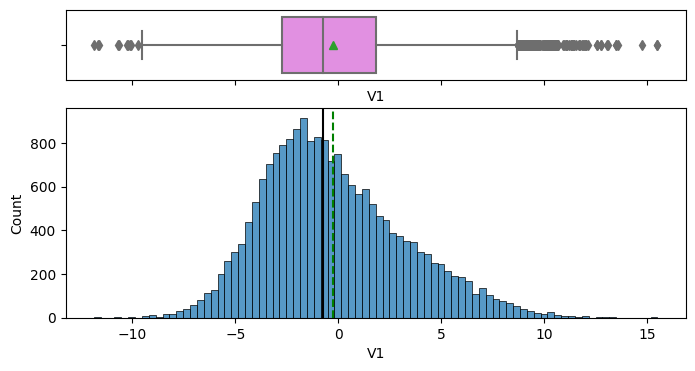

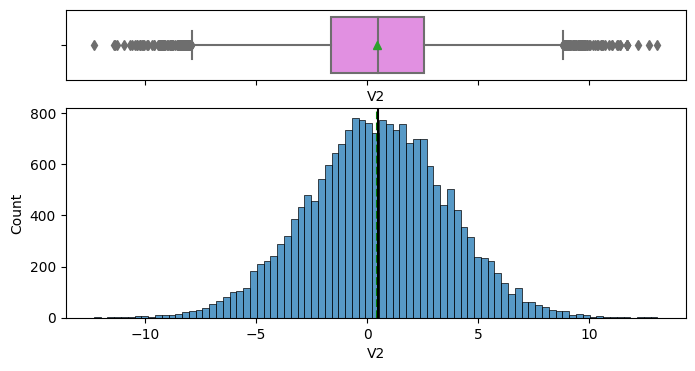

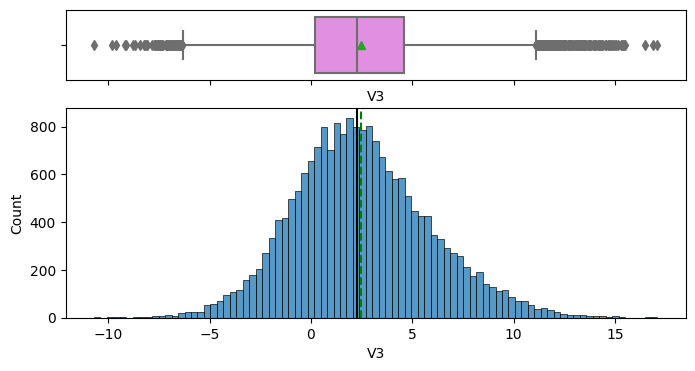

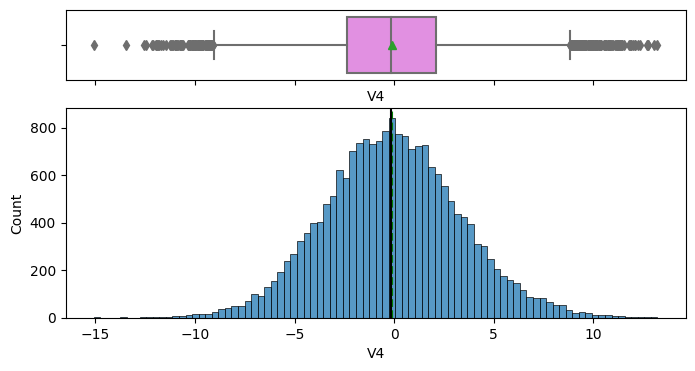

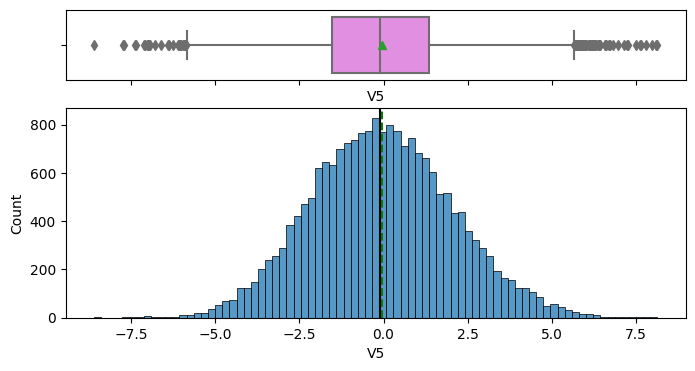

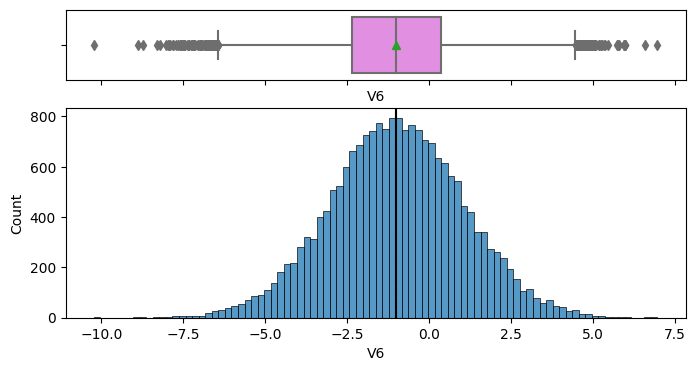

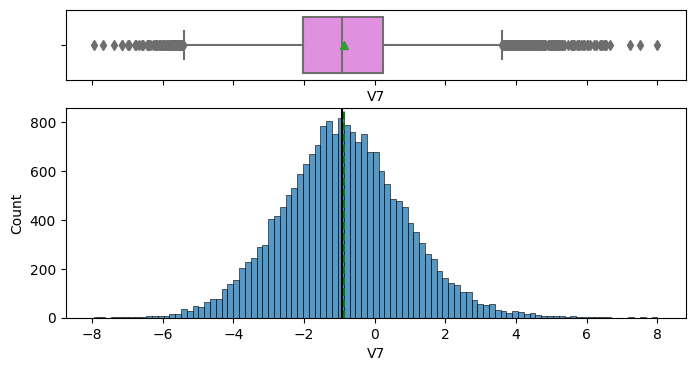

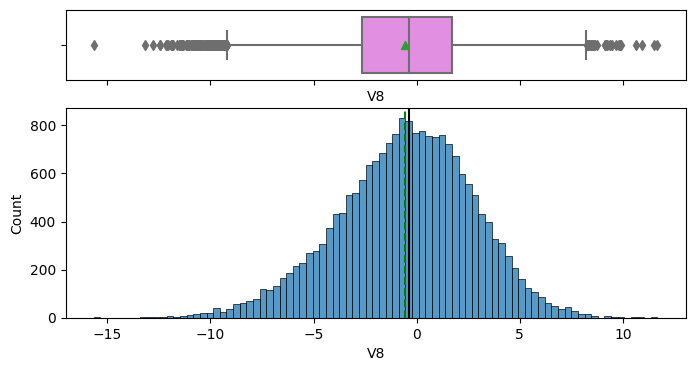

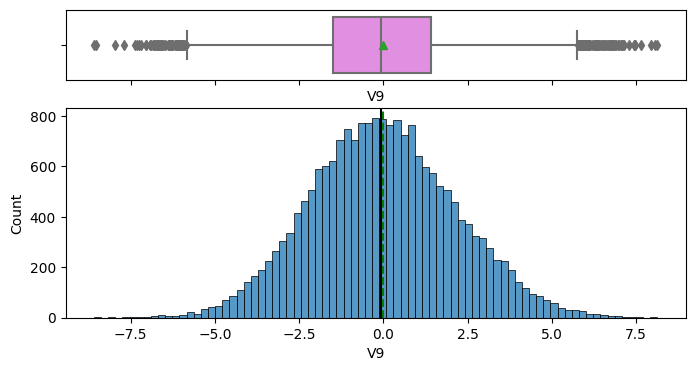

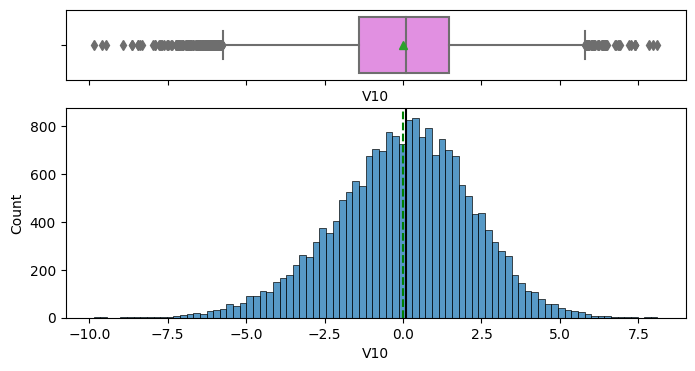

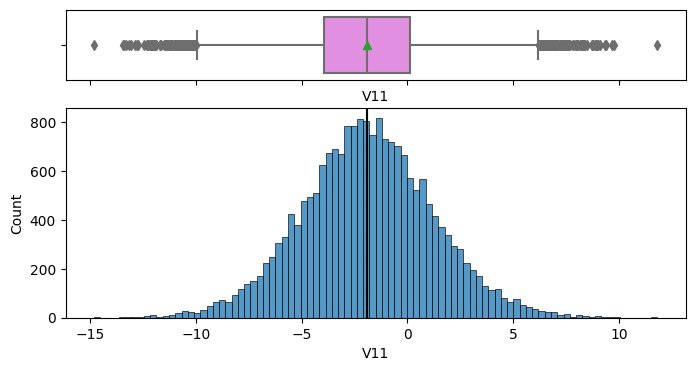

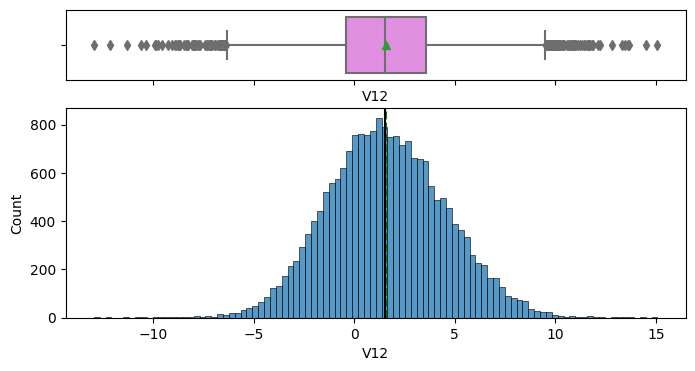

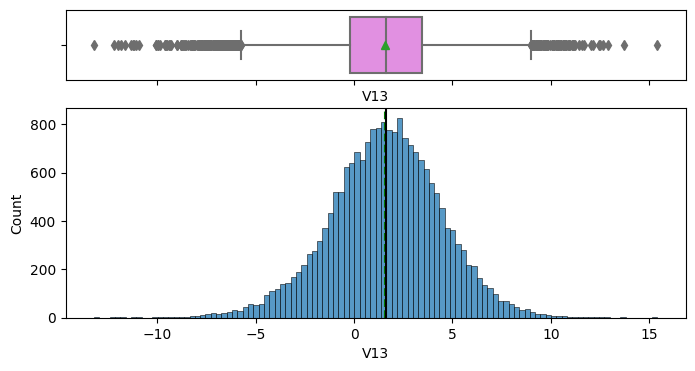

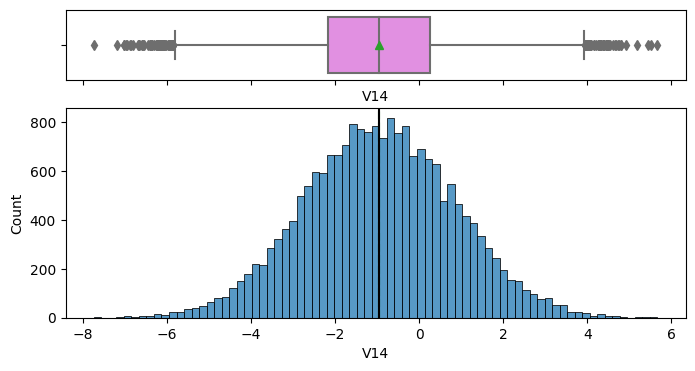

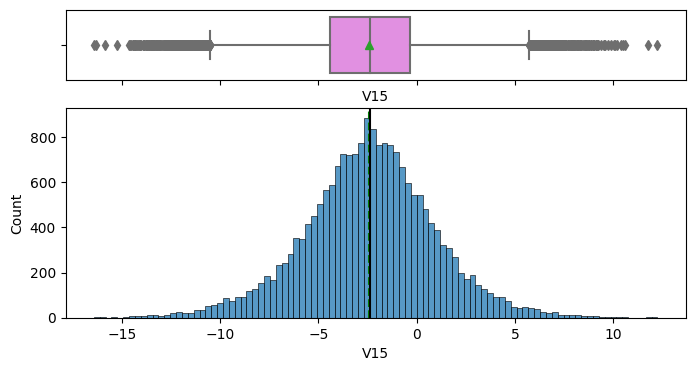

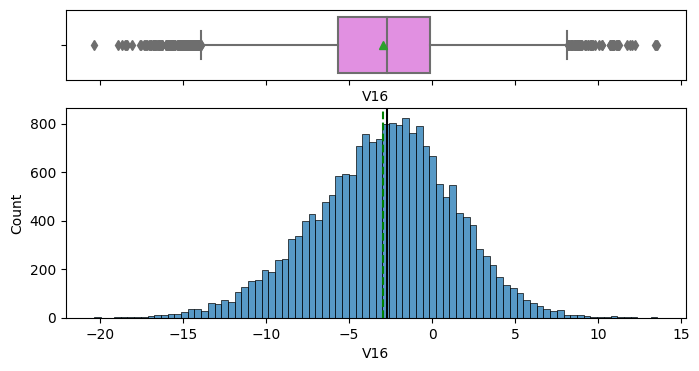

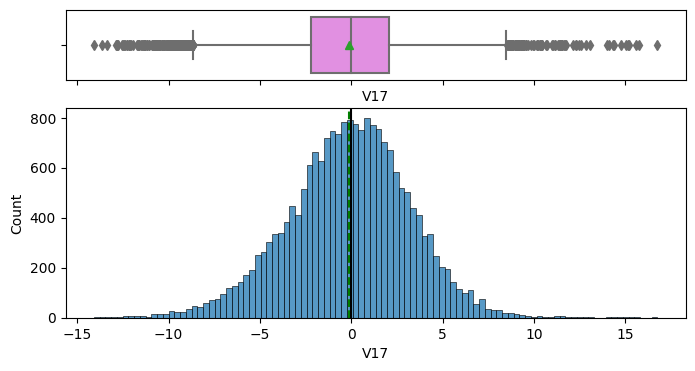

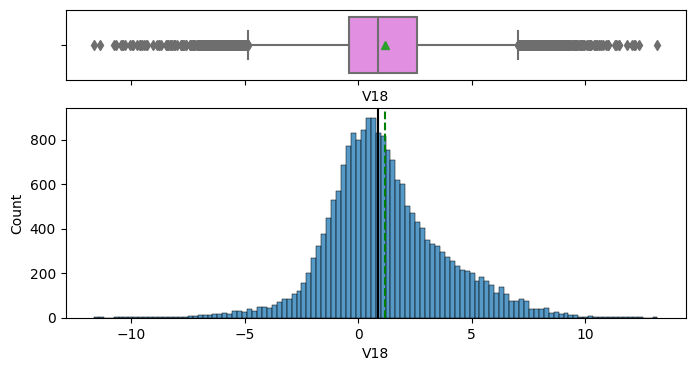

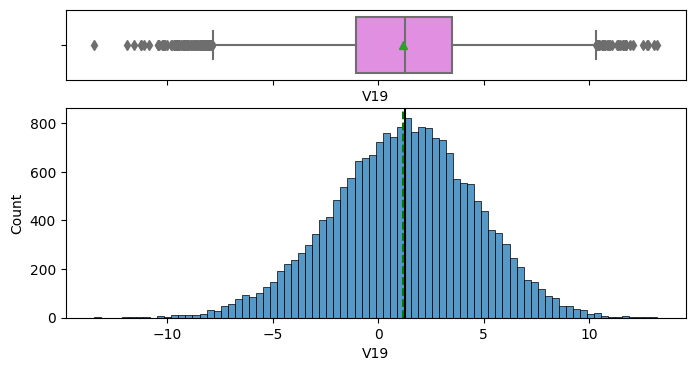

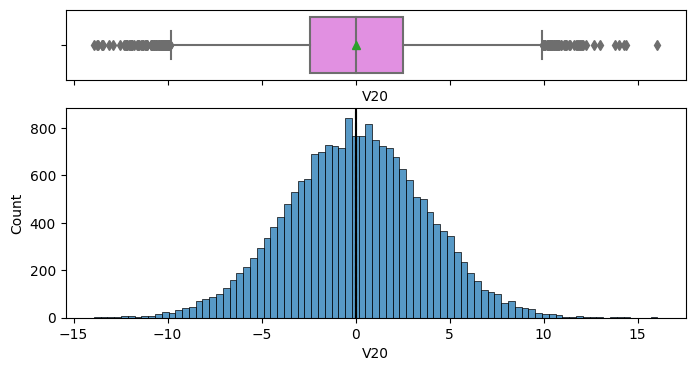

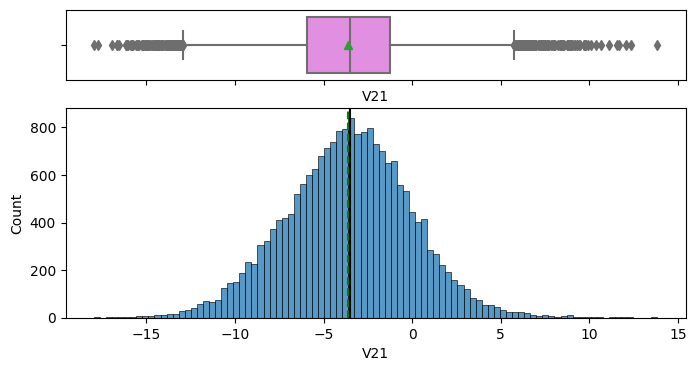

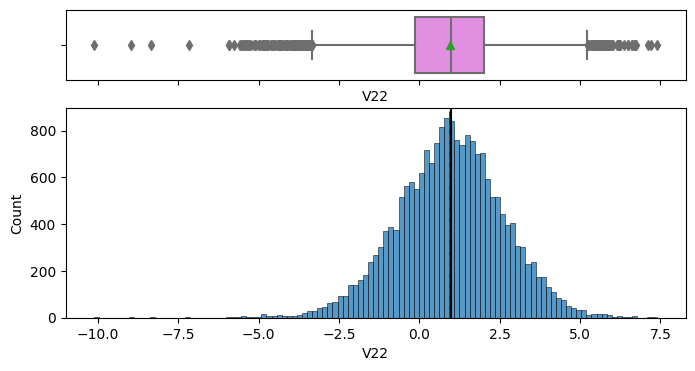

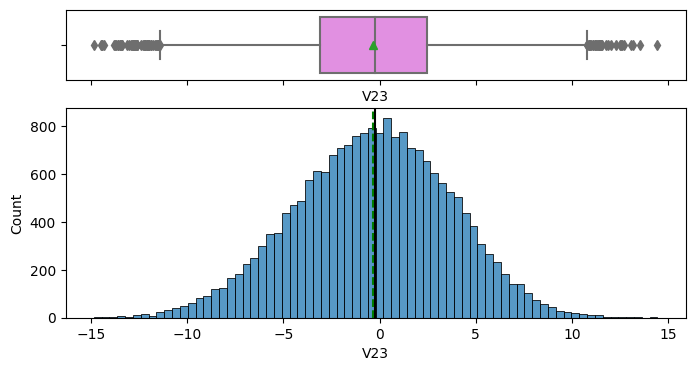

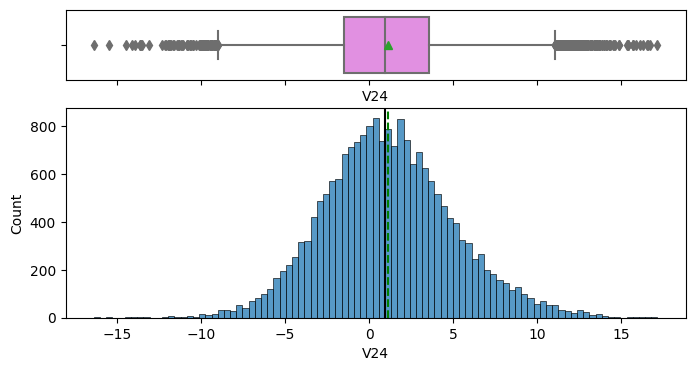

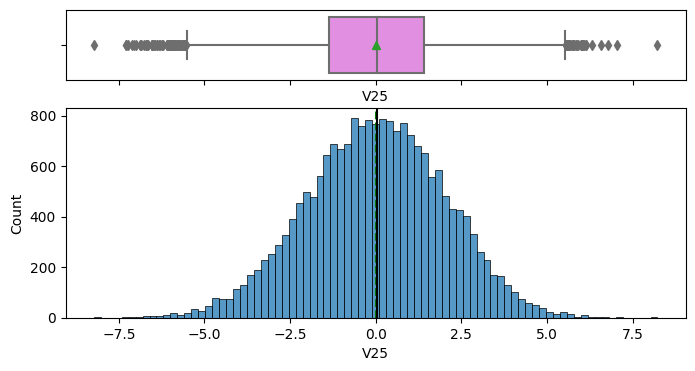

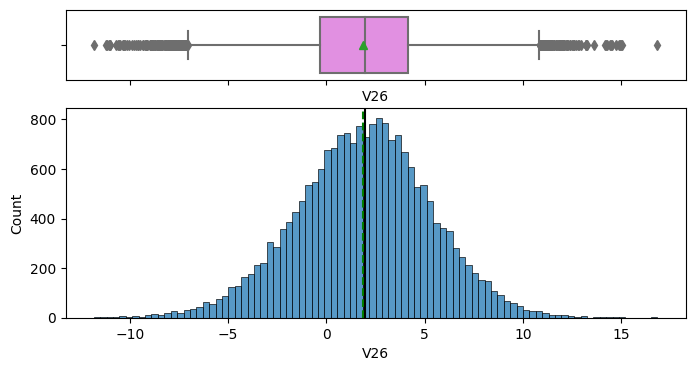

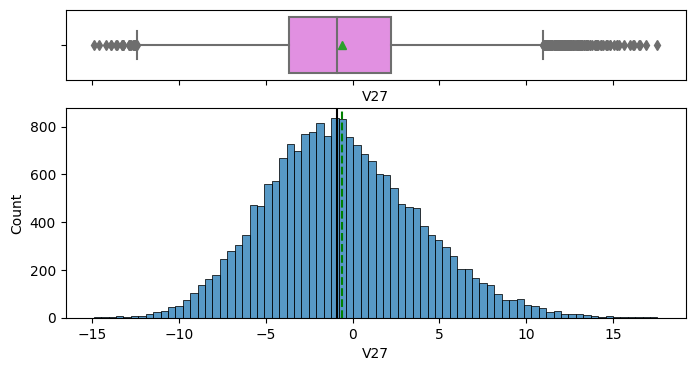

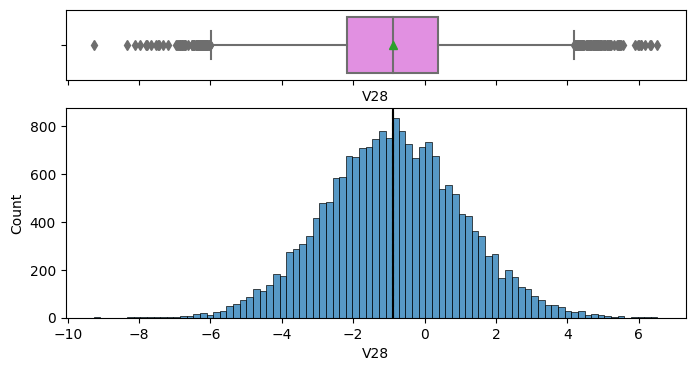

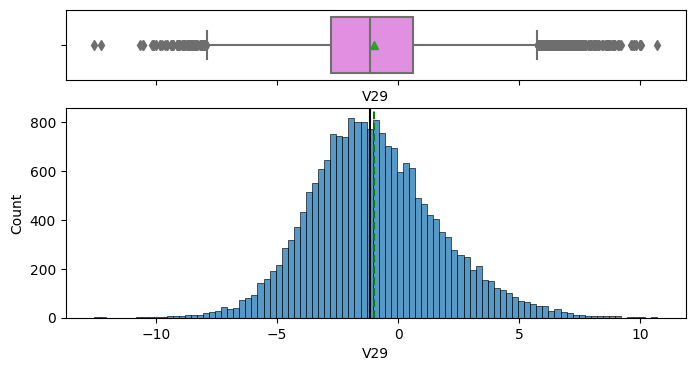

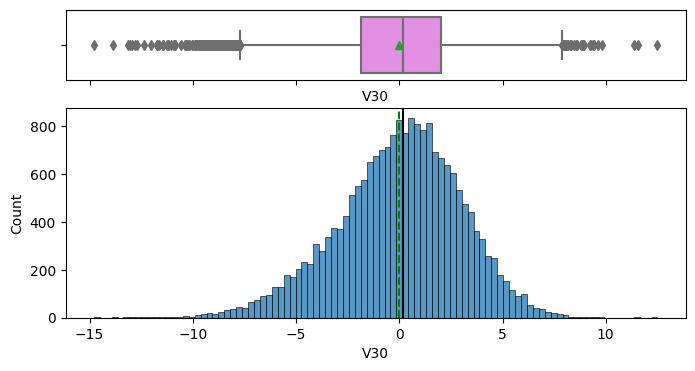

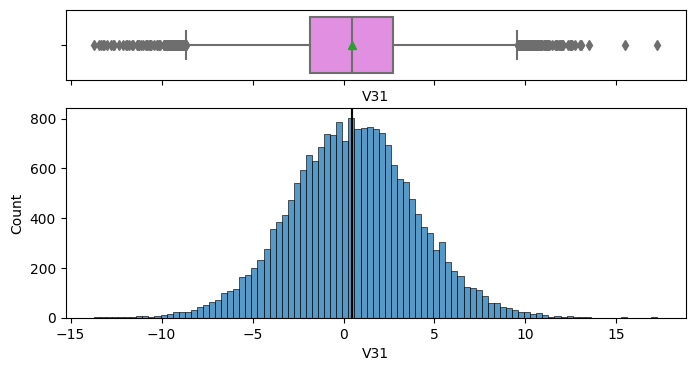

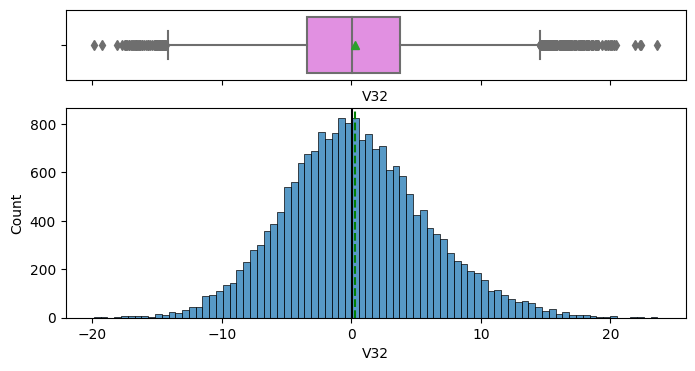

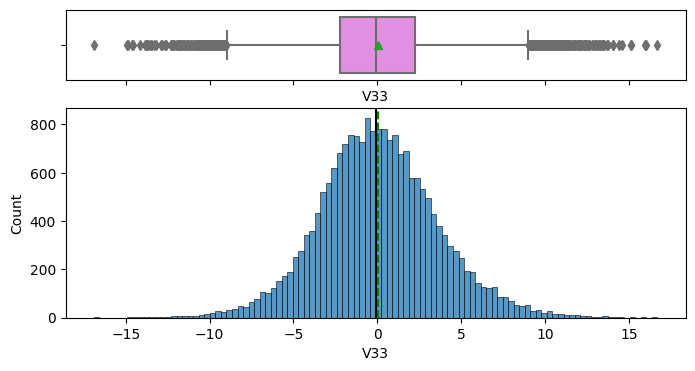

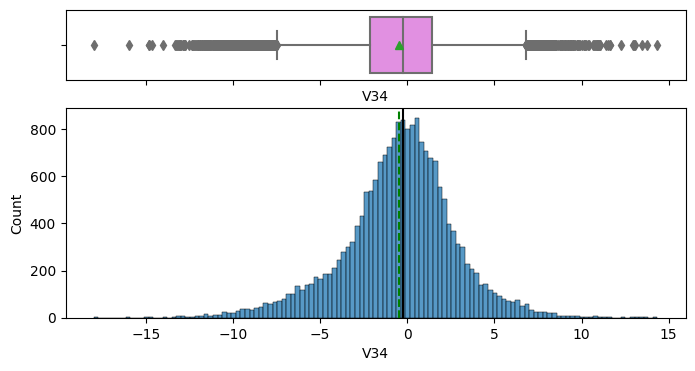

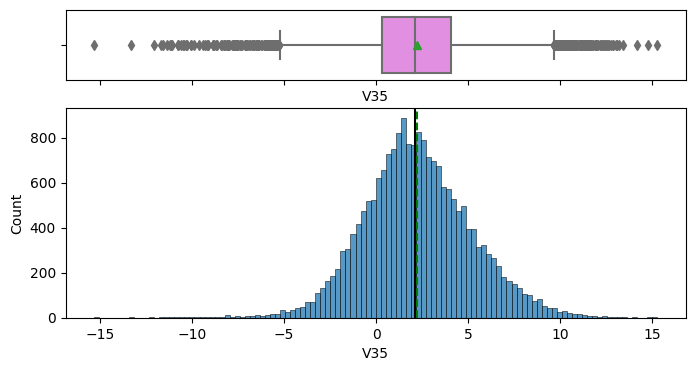

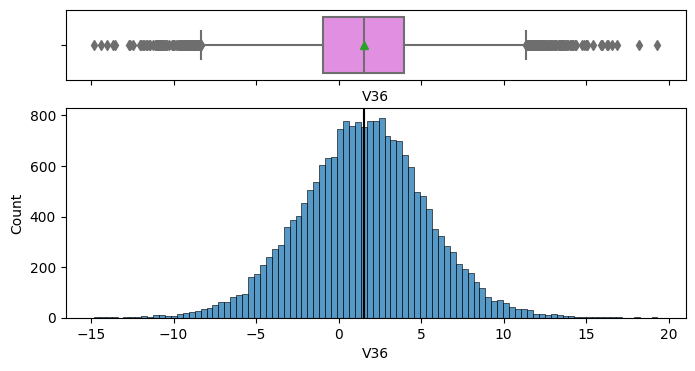

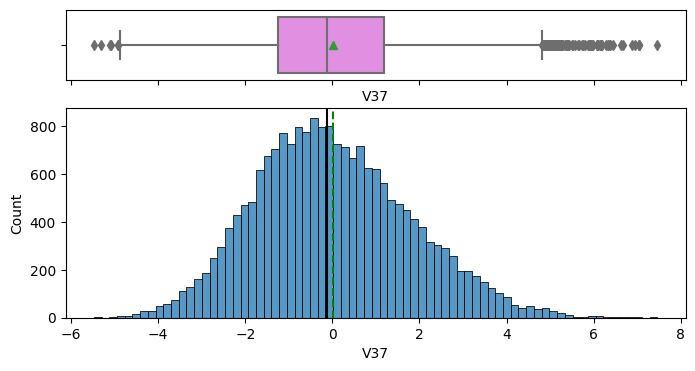

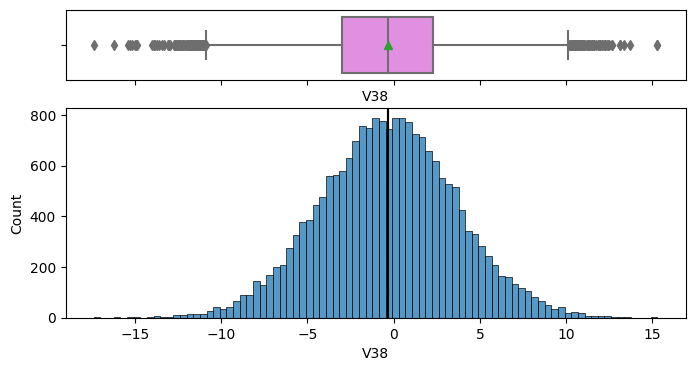

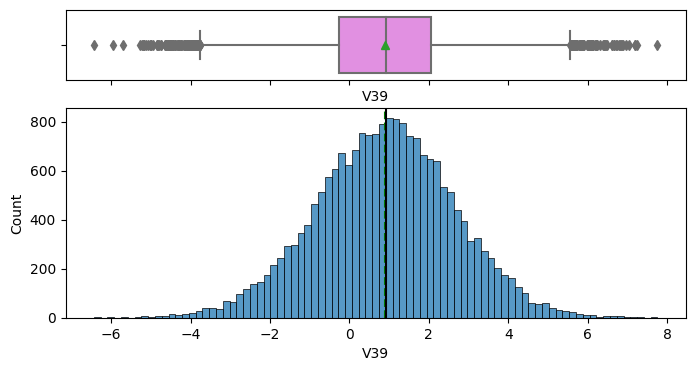

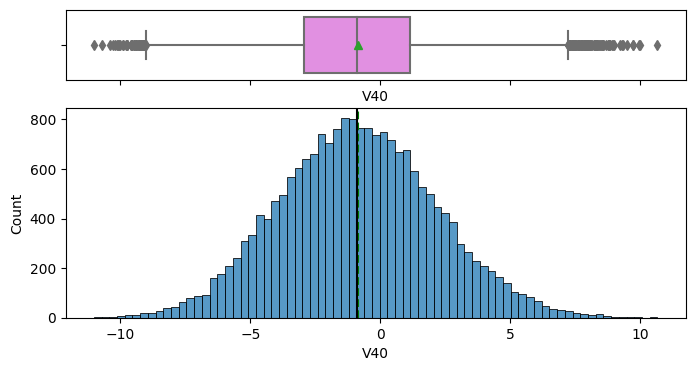

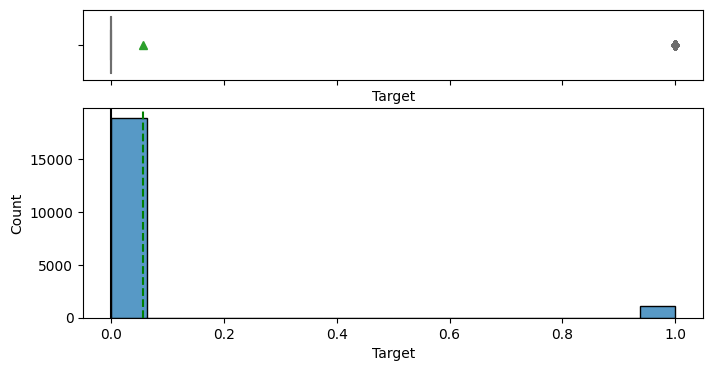

In [26]:
for feature in df_train.columns:
    histogram_boxplot(df_train, feature, figsize=(8,4), kde=False, bins=None)  
    plt.show()

### Observations 
- The variable show relatively normal distribution but have many outliers
- Since non-linear models are robust to outliers and multicollinearity, the data wont be treated.

## Data PreProcessing 
- Fill in missing values in both the train and test dataset

In [27]:
## lets compute the mean of the respective column and use it to replace the missing values 
df_train['V1'] = df_train['V1'].fillna(df_train['V1'].mean())
df_train['V2'] = df_train['V2'].fillna(df_train['V1'].mean())

In [28]:
## lets compute the mean of the respective column and use it to replace the missing values 
df_test['V1'] = df_test['V1'].fillna(df_test['V1'].mean())
df_test['V2'] = df_test['V2'].fillna(df_train['V2'].mean())

In [29]:
## Lets confirm to see if there is no missing data for the train set
df_train.isnull().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64

In [30]:
## Lets confirm to see if there is no missing data for the test set
df_test.isnull().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64

In [31]:
y_train = df_train['Target']
X_train = df_train.drop(['Target'], axis=1)

y_test = df_test['Target']
X_test = df_test.drop(['Target'], axis=1)

### Data Standardization
- Perform data standardization to normalize the features in the dataset

In [32]:
## lets create an instance of the standard scaler
scaler = StandardScaler() 

## fit and transform the features 
scaled_X_train = pd.DataFrame(scaler.fit_transform(X_train))
scaled_X_train.columns = X_train.columns

scaled_X_test = pd.DataFrame(scaler.fit_transform(X_test))
scaled_X_test.columns = X_test.columns

### Observations
- The data has successfully been scaled

## Building A Validation Framework / Splitting Dataset
- Shuffle the initial dataset, use seed 
- Split your data in train/val with 80%/20% distribution.

In [33]:
## lets split the training data into train set and validation set
X_train, X_valid, y_train, y_valid = train_test_split(scaled_X_train, y_train, test_size=0.2, random_state=11)

print(f"Training Size: {len(X_train)}")
print(f"Validation Size: {len(X_valid)}")

Training Size: 16000
Validation Size: 4000


In [34]:
## lets convert all the target dataframe to 1-D vector array
y_train = y_train.values 
y_valid = y_valid.values
y_test = y_test.values

In [35]:
## convert all features dataframe to numpy matrix array
X_train = X_train.values
X_valid = X_valid.values
X_test = scaled_X_test.values

## Observations
- The trainig set now is made of 16000 rows and the validation set is now made up 4000

## Model Building

### Model evaluation criterion 
The nature of predictions made by the classification model will translate as follows:
- True positives (TP) are failuers correctly predicted by the model. 
- False negatives (FN) are real failuers in a generator where there is no detection by model.
- False positives (FP) are failuers detections in a generator where there isno failure. 
### Metric to optimize 
- Lets select the metric that ensures that the maximum number of genrator failuers are predicted correctly by the model
- Lets maximize Recall because the greater the Recall, the higher the chances of minimzing false negatives
- The goal is to minimize false negatives because if a model predicts that a machine will have no failure when there is an actual failuer then it will increase the maintenance cost. 

### Lets create a function to define the following 
- compute performance for classification model
- compute the confusion matrix

In [36]:
## define a function to compute difference metrics score
## to check the performance of the classification model
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classifcation model performance
    
    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    ## generate predictions using independent variables
    pred = model.predict(predictors)

    ## calculating the accuracy
    acc = accuracy_score(target, pred)
    ## calculating the Recall
    recall = recall_score(target, pred)
    ## calculating the Precision
    precision = precision_score(target, pred)
    ## calculating the F1-Score
    f1 = f1_score(target, pred)

    ## creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        }, 
        index=[0],
    )

    return df_perf

In [37]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    function to plot the confusion matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variables  
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2,2)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Define scorer to be used for cross validation and hyperparameter tuning 
- Lets reduce false negatives and try to mazimize "Recall" 
- To maximize Recall, lets use Recall as a scorer in cross-validation and hyperparameter tuning

In [38]:
## type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

### Building a Baseline Models
- This serves as a point of reference for comparing the performance of more complex models

#### Model Building with Original Dataset

In [39]:
## lets create a list of all the classification ML models to use for training

## empty list to store all the models
models = []

## append models to the list
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("Bagging Classifier", BaggingClassifier(random_state=1)))
models.append(("Decision Tree Classifier", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost Classifier", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting Classifier", GradientBoostingClassifier(random_state=1)))
models.append(("Random Forest Classifier", RandomForestClassifier(random_state=1)))
models.append(("XGB Classifier", XGBClassifier(random_state=1)))

## empty list to store all models scores
results = []

## empty list to store names of models
names = []

## lets loop through all the models and get the mean cross validation score
print("\n" "Cross-Validation Score On Training Data:" "\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    
    cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold)

    results.append(cv_result)
    names.append(name)

    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    y_valid_pred = model.predict(X_valid)
    scores = recall_score(y_valid, y_valid_pred)
    print("{}: {}".format(name, scores))


Cross-Validation Score On Training Data:

Logistic Regression: 0.47262569832402235
Bagging Classifier: 0.7027932960893855
Decision Tree Classifier: 0.7195530726256983
AdaBoost Classifier: 0.5910614525139666
Gradient Boosting Classifier: 0.7150837988826815
Random Forest Classifier: 0.7284916201117319
XGB Classifier: 0.805586592178771

Validation Performance:

Logistic Regression: 0.5534883720930233
Bagging Classifier: 0.7395348837209302
Decision Tree Classifier: 0.7302325581395349
AdaBoost Classifier: 0.6232558139534884
Gradient Boosting Classifier: 0.7674418604651163
Random Forest Classifier: 0.7627906976744186
XGB Classifier: 0.8186046511627907


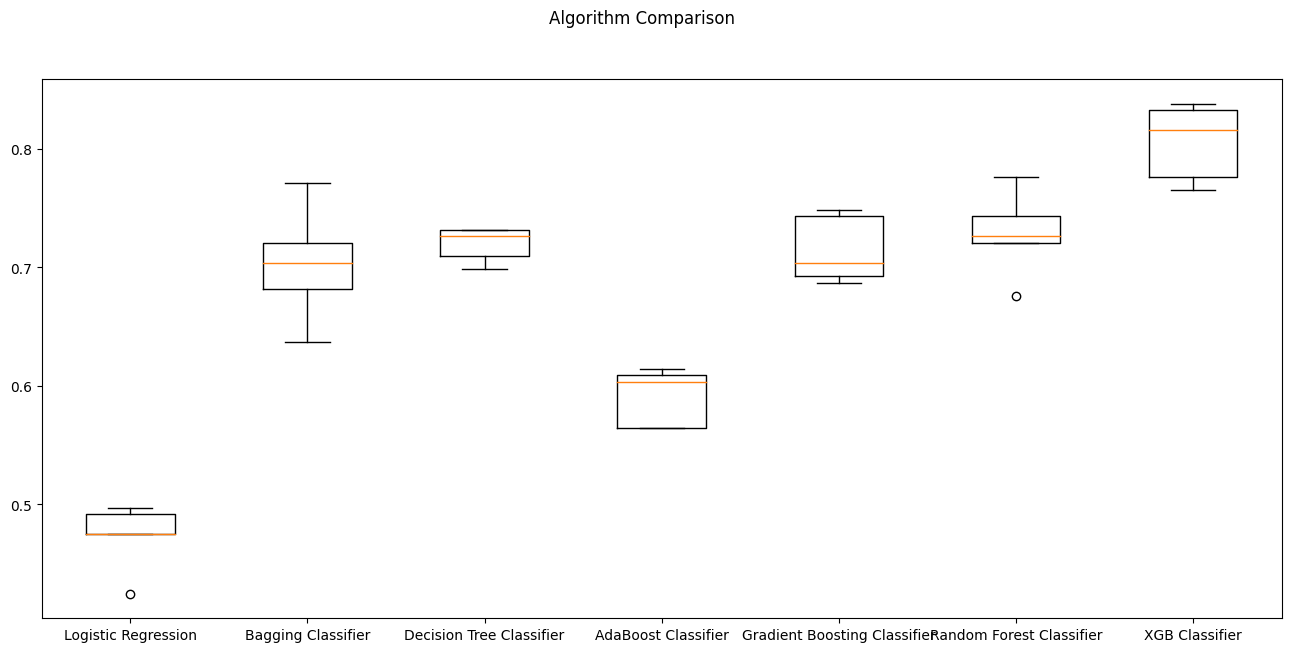

In [40]:
## plotting boxplots for CV scores of all baseline models defined above 
fig = plt.figure(figsize=(16, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

#### Model Building with Oversampled data 
- This method is to treat the highly biased dataset.

In [41]:
## lets perform synthetic minority over sampling technique 
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=11)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [42]:
print(f"Before OverSampling, count of label '1': {sum(y_train == 1)}")
print(f"Before OverSampling, count of label '0': {sum(y_train == 0)}")

print(f"After OverSampling, count of label '1': {sum(y_train_over == 1)}")
print(f"After OverSampling, count of label '0': {sum(y_train_over == 0)}")

print(f"After OverSampling, the shape of X_train: {X_train_over.shape}")
print(f"After OverSampling, the shape of y_train: {y_train_over.shape}")

Before OverSampling, count of label '1': 895
Before OverSampling, count of label '0': 15105
After OverSampling, count of label '1': 15105
After OverSampling, count of label '0': 15105
After OverSampling, the shape of X_train: (30210, 40)
After OverSampling, the shape of y_train: (30210,)


In [43]:
## lets create a list of all the classification ML models to use for training

## empty list to store all the models
models = []

## append models to the list
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("Bagging Classifier", BaggingClassifier(random_state=1)))
models.append(("Decision Tree Classifier", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost Classifier", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting Classifier", GradientBoostingClassifier(random_state=1)))
models.append(("Random Forest Classifier", RandomForestClassifier(random_state=1)))
models.append(("XGB Classifier", XGBClassifier(random_state=1)))

## empty list to store all models scores
results = []

## empty list to store names of models
names = []

## lets loop through all the models and get the mean cross validation score
print("\n" "Cross-Validation Score On Oversampled Data:" "\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    
    cv_result = cross_val_score(estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold)

    results.append(cv_result)
    names.append(name)

    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance on Oversampled:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    y_valid_pred = model.predict(X_valid)
    scores = recall_score(y_valid, y_valid_pred)
    print("{}: {}".format(name, scores))


Cross-Validation Score On Oversampled Data:

Logistic Regression: 0.8771929824561404
Bagging Classifier: 0.9763654419066533
Decision Tree Classifier: 0.9666997682886462
AdaBoost Classifier: 0.8968553459119496
Gradient Boosting Classifier: 0.923601456471367
Random Forest Classifier: 0.9847732538894405
XGB Classifier: 0.9911287653095002

Validation Performance on Oversampled:

Logistic Regression: 0.8744186046511628
Bagging Classifier: 0.8232558139534883
Decision Tree Classifier: 0.7581395348837209
AdaBoost Classifier: 0.8465116279069768
Gradient Boosting Classifier: 0.8976744186046511
Random Forest Classifier: 0.8372093023255814
XGB Classifier: 0.8744186046511628


### Observations 
- The cross-validation score for recall improved across all the model 
- Overfitting is still an issue for all the models 
- The performance of the model on the validation data improved

#### Building Model with Undersampled data

In [44]:
## lets perform synthetic minority over sampling technique 
sm = RandomUnderSampler(sampling_strategy=1,  random_state=11)
X_train_under, y_train_under = sm.fit_resample(X_train, y_train)

In [45]:
print(f"Before UnderSampling, count of label '1': {sum(y_train == 1)}")
print(f"Before UnderSampling, count of label '0': {sum(y_train == 0)}")

print(f"After UnderSampling, count of label '1': {sum(y_train_under == 1)}")
print(f"After UnderSampling, count of label '0': {sum(y_train_under == 0)}")

print(f"After UnderSampling, the shape of X_train: {X_train_under.shape}")
print(f"After UnderSampling, the shape of y_train: {y_train_under.shape}")

Before UnderSampling, count of label '1': 895
Before UnderSampling, count of label '0': 15105
After UnderSampling, count of label '1': 895
After UnderSampling, count of label '0': 895
After UnderSampling, the shape of X_train: (1790, 40)
After UnderSampling, the shape of y_train: (1790,)


In [46]:
## lets create a list of all the classification ML models to use for training

## empty list to store all the models
models = []

## append models to the list
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("Bagging Classifier", BaggingClassifier(random_state=1)))
models.append(("Decision Tree Classifier", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost Classifier", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting Classifier", GradientBoostingClassifier(random_state=1)))
models.append(("Random Forest Classifier", RandomForestClassifier(random_state=1)))
models.append(("XGB Classifier", XGBClassifier(random_state=1)))

## empty list to store all models scores
results = []

## empty list to store names of models
names = []

## lets loop through all the models and get the mean cross validation score
print("\n" "Cross-Validation Score On UnderSampled Data:" "\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    
    cv_result = cross_val_score(estimator=model, X=X_train_under, y=y_train_under, scoring=scorer, cv=kfold)

    results.append(cv_result)
    names.append(name)

    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance on UnderSampled:" "\n")

for name, model in models:
    model.fit(X_train_under, y_train_under)
    y_valid_pred = model.predict(X_valid)
    scores = recall_score(y_valid, y_valid_pred)
    print("{}: {}".format(name, scores))


Cross-Validation Score On UnderSampled Data:

Logistic Regression: 0.8525139664804471
Bagging Classifier: 0.8681564245810055
Decision Tree Classifier: 0.8558659217877095
AdaBoost Classifier: 0.8770949720670391
Gradient Boosting Classifier: 0.8871508379888267
Random Forest Classifier: 0.8938547486033519
XGB Classifier: 0.8893854748603351

Validation Performance on UnderSampled:

Logistic Regression: 0.8837209302325582
Bagging Classifier: 0.9023255813953488
Decision Tree Classifier: 0.8325581395348837
AdaBoost Classifier: 0.8697674418604651
Gradient Boosting Classifier: 0.8883720930232558
Random Forest Classifier: 0.8976744186046511
XGB Classifier: 0.9069767441860465


## Hyperparamter Tuning 
** To avoid long time runs during Hyperparameter tuning, this sections uses the following grids to avoid the time complexity. 
- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6), 
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}


- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7], 
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1], 
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}



- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

### Logistic Regression with Random Search on Original Data

In [47]:
## define the model 
Model = LogisticRegression(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {'C': np.arange(0.1,1.1,0.1)}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'C': 0.2} with CV score= 0.47150837988826816


In [48]:
## lets build the model with the best parameter
tuned_log_reg_model_og = LogisticRegression(
    random_state=11,
    C=0.2
)

tuned_log_reg_model_og.fit(X_train, y_train)

LogisticRegression(C=0.2, random_state=11)

In [49]:
## lets compute the metrics on the train set 
tuned_log_reg_og_train_perf = model_performance_classification_sklearn(tuned_log_reg_model_og, X_train, y_train)
tuned_log_reg_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.9655,0.472626,0.840954,0.60515


In [50]:
## lets compute the metrics on the validation set

tuned_log_reg_og_valid_perf = model_performance_classification_sklearn(tuned_log_reg_model_og, X_valid, y_valid)
tuned_log_reg_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.972,0.553488,0.881481,0.68


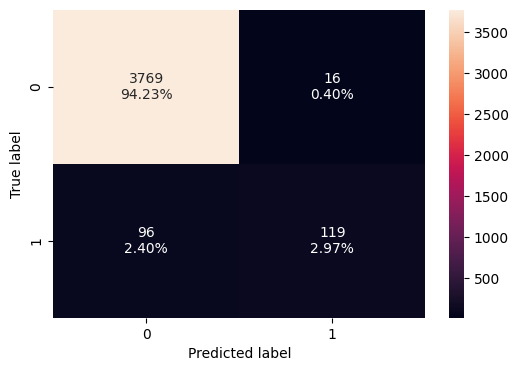

In [51]:
## lets plot the confusion matric table for orginal dataset
confusion_matrix_sklearn(tuned_log_reg_model_og, X_valid, y_valid)

### Logistic Regression with Random Search on UnderSampled Data

In [52]:
## define the model 
Model = LogisticRegression(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {'C': np.arange(0.1,1.1,0.1)}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'C': 0.1} with CV score= 0.8558659217877095


In [53]:
tuned_log_reg_model_un = LogisticRegression(
    random_state=11,
    C=0.1
)

tuned_log_reg_model_un.fit(X_train_under, y_train_under)

LogisticRegression(C=0.1, random_state=11)

In [54]:
## ## lets compute the metrics on the train set 
tuned_log_reg_un_train_perf = model_performance_classification_sklearn(tuned_log_reg_model_un, X_train_under, y_train_under)
tuned_log_reg_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.860894,0.856983,0.863739,0.860348


In [55]:
## lets compute the metrics on the validation set

tuned_log_reg_un_valid_perf = model_performance_classification_sklearn(tuned_log_reg_model_un, X_valid, y_valid)
tuned_log_reg_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.8585,0.883721,0.259918,0.401691


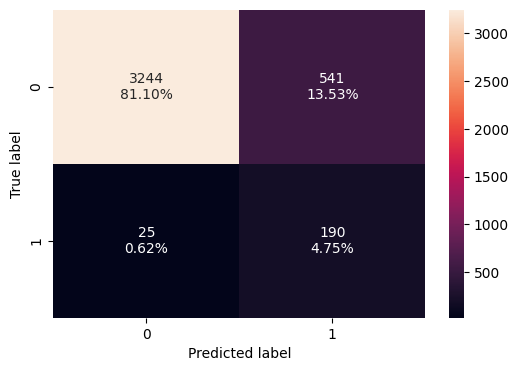

In [56]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_log_reg_model_un, X_valid, y_valid)

### Logistic Regression with Random Search on OverSampled Data

In [57]:
## define the model 
Model = LogisticRegression(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {'C': np.arange(0.1,1.1,0.1)}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'C': 0.1} with CV score= 0.8769943727242634


In [58]:
tuned_log_reg_model_ov = LogisticRegression(
    random_state=11,
    C=0.1
)

tuned_log_reg_model_ov.fit(X_train_over, y_train_over)

LogisticRegression(C=0.1, random_state=11)

In [59]:
## ## lets compute the metrics on the train set 
tuned_log_reg_ov_train_perf = model_performance_classification_sklearn(tuned_log_reg_model_ov, X_train_over, y_train_over)
tuned_log_reg_ov_train_perf

,Accuracy,Recall,Precision,F1
0,0.874843,0.877193,0.873089,0.875136


In [60]:
## ## lets compute the metrics on the valid set 
tuned_log_reg_ov_valid_perf = model_performance_classification_sklearn(tuned_log_reg_model_ov, X_valid, y_valid)
tuned_log_reg_ov_valid_perf

,Accuracy,Recall,Precision,F1
0,0.869,0.874419,0.274453,0.417778


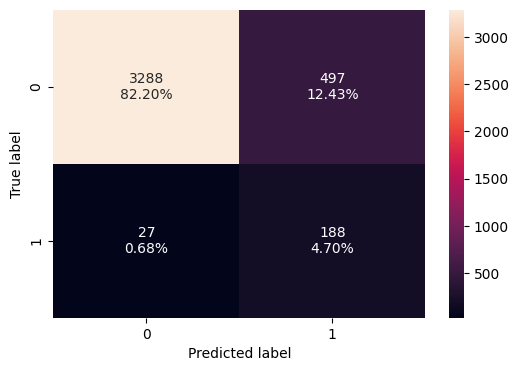

In [61]:
## lets plot the confusion matric table for oversampled dataset
confusion_matrix_sklearn(tuned_log_reg_model_ov, X_valid, y_valid)

### Random Forest with Random Search on Original Data

In [62]:
## define the model 
Model = RandomForestClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score= 0.7050279329608939


In [63]:
tuned_rf_clf_model_og = RandomForestClassifier(
    random_state = 1, 
    n_estimators= 200,
    min_samples_leaf= 1, 
    max_samples= 0.6, 
    max_features= 'sqrt'
    
)

tuned_rf_clf_model_og.fit(X_train, y_train)

RandomForestClassifier(max_samples=0.6, n_estimators=200, random_state=1)

In [64]:
## lets compute the metrics on the train set 
tuned_rf_clf_og_train_perf = model_performance_classification_sklearn(tuned_rf_clf_model_og, X_train, y_train)
tuned_rf_clf_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.995,0.911732,0.998776,0.953271


In [65]:
## lets compute the metrics on the train set 
tuned_rf_clf_og_valid_perf = model_performance_classification_sklearn(tuned_rf_clf_model_og, X_valid, y_valid)
tuned_rf_clf_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.9865,0.748837,1.0,0.856383


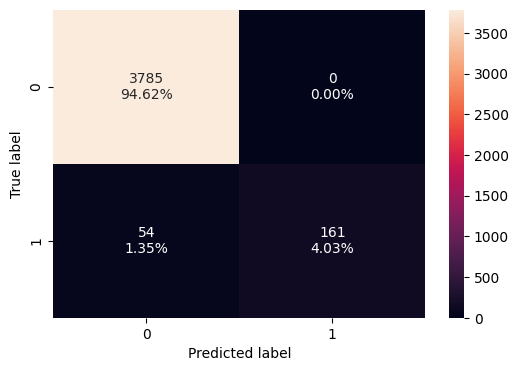

In [66]:
## lets plot the confusion matric table for original dataset
confusion_matrix_sklearn(tuned_rf_clf_model_og, X_valid, y_valid)

### Random Forest with Random Search on UnderSampled Data

In [67]:
## define the model 
Model = RandomForestClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 250, 'min_samples_leaf': 2, 'max_samples': 0.5, 'max_features': 'sqrt'} with CV score= 0.8927374301675977


In [68]:
tuned_rf_clf_model_under = RandomForestClassifier(
    random_state = 1, 
    n_estimators= 250,
    min_samples_leaf= 2, 
    max_samples= 0.5, 
    max_features= 'sqrt'
    
)

tuned_rf_clf_model_under.fit(X_train_under, y_train_under)

RandomForestClassifier(max_samples=0.5, min_samples_leaf=2, n_estimators=250,
                       random_state=1)

In [69]:
## lets compute the metrics on the train set 
tuned_rf_clf_un_train_perf = model_performance_classification_sklearn(tuned_rf_clf_model_under, X_train_under, y_train_under)
tuned_rf_clf_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.964246,0.935196,0.992883,0.963176


In [70]:
## lets compute the metrics on the train set 
tuned_rf_clf_un_valid_perf = model_performance_classification_sklearn(tuned_rf_clf_model_under, X_valid, y_valid)
tuned_rf_clf_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.946,0.902326,0.498715,0.642384


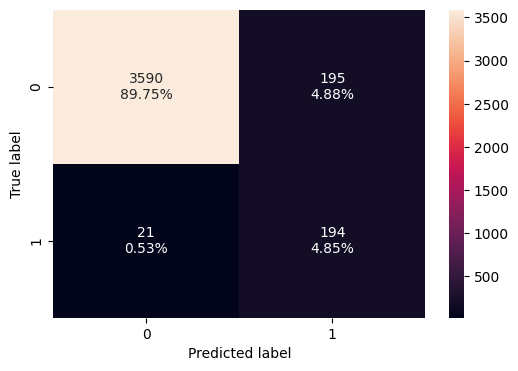

In [71]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_rf_clf_model_under, X_valid, y_valid)

### Random Forest with Random Search on OverSampled Data

In [72]:
## define the model 
Model = RandomForestClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score= 0.9815292949354518


In [73]:
tuned_rf_clf_model_ov = RandomForestClassifier(
    random_state = 1, 
    n_estimators= 300,
    min_samples_leaf= 1, 
    max_samples= 0.6, 
    max_features= 'sqrt'
    
)

tuned_rf_clf_model_ov.fit(X_train_over, y_train_over)

RandomForestClassifier(max_samples=0.6, n_estimators=300, random_state=1)

In [74]:
## lets compute the metrics on the train set 
tuned_rf_clf_ov_train_perf = model_performance_classification_sklearn(tuned_rf_clf_model_ov, X_train_over, y_train_over)
tuned_rf_clf_ov_train_perf

,Accuracy,Recall,Precision,F1
0,0.999702,0.999603,0.999801,0.999702


In [75]:
## lets compute the metrics on the train set 
tuned_rf_clf_over_valid_perf = model_performance_classification_sklearn(tuned_rf_clf_model_ov, X_valid, y_valid)
tuned_rf_clf_over_valid_perf

,Accuracy,Recall,Precision,F1
0,0.98925,0.860465,0.934343,0.895884


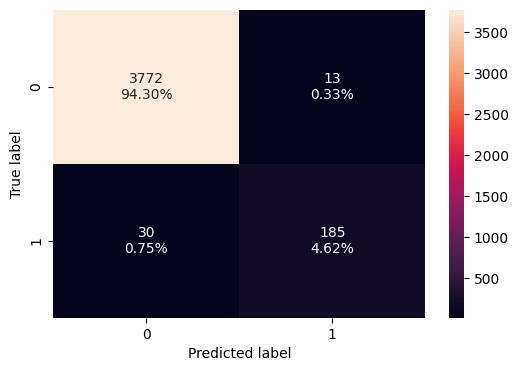

In [76]:
## lets plot the confusion matric table for oversampled dataset
confusion_matrix_sklearn(tuned_rf_clf_model_ov, X_valid, y_valid)

### Decision Trees with Random Search on Orginal Data

In [77]:
## define the model 
Model = DecisionTreeClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV

param_grid = {
    'max_depth': np.arange(2,6), 
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}


## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'min_samples_leaf': 7, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': 5} with CV score= 0.5508379888268157


In [78]:
tuned_tree_clf_model_og = DecisionTreeClassifier(
    random_state=1,
    min_samples_leaf = 7, 
    min_impurity_decrease = 0.0001,
    max_leaf_nodes = 15, 
    max_depth = 5

)

tuned_tree_clf_model_og.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, min_samples_leaf=7,
                       random_state=1)

In [79]:
## lets compute the metrics on the train set 
tuned_tree_clf_og_train_perf = model_performance_classification_sklearn(tuned_tree_clf_model_og, X_train, y_train)
tuned_tree_clf_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.972313,0.598883,0.864516,0.707591


In [80]:
## lets compute the metrics on the valid set 
tuned_tree_clf_og_valid_perf = model_performance_classification_sklearn(tuned_tree_clf_model_og, X_valid, y_valid)
tuned_tree_clf_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.97475,0.618605,0.875,0.724796


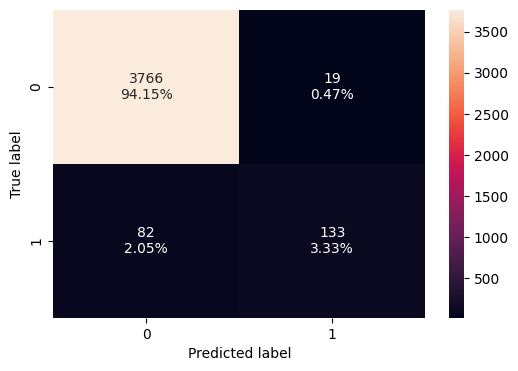

In [81]:
## lets plot the confusion matric table for original dataset
confusion_matrix_sklearn(tuned_tree_clf_model_og, X_valid, y_valid)

### Decision Trees with Random Search on UnderSampled Data

In [82]:
## define the model 
Model = DecisionTreeClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV

param_grid = {
    'max_depth': np.arange(2,6), 
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}


## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': 4} with CV score= 0.8301675977653631


In [83]:
tuned_tree_clf_model_un = DecisionTreeClassifier(
    random_state=1,
    min_samples_leaf = 1, 
    min_impurity_decrease = 0.0001,
    max_leaf_nodes = 15, 
    max_depth = 4

)

tuned_tree_clf_model_un.fit(X_train_under, y_train_under)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, random_state=1)

In [84]:
## lets compute the metrics on the train set 
tuned_tree_clf_un_train_perf = model_performance_classification_sklearn(tuned_tree_clf_model_un, X_train, y_train)
tuned_tree_clf_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.904,0.850279,0.351826,0.497711


In [85]:
## lets compute the metrics on the train set 
tuned_tree_clf_un_valid_perf = model_performance_classification_sklearn(tuned_tree_clf_model_un, X_valid, y_valid)
tuned_tree_clf_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.8915,0.809302,0.306878,0.445013


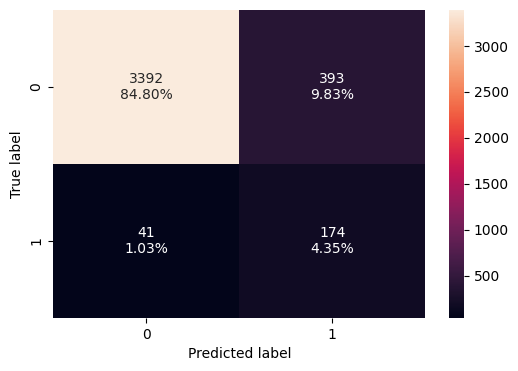

In [86]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_tree_clf_model_un, X_valid, y_valid)

### Decision Trees with Random Search on OverSampled Data

In [87]:
## define the model 
Model = DecisionTreeClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV

param_grid = {
    'max_depth': np.arange(2,6), 
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}


## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 10, 'max_depth': 3} with CV score= 0.9108904336312479


In [88]:
tuned_tree_clf_model_ov = DecisionTreeClassifier(
    random_state=1,
    min_samples_leaf = 1, 
    min_impurity_decrease = 0.0001,
    max_leaf_nodes = 10, 
    max_depth = 3

)

tuned_tree_clf_model_ov.fit(X_train_over, y_train_over)

DecisionTreeClassifier(max_depth=3, max_leaf_nodes=10,
                       min_impurity_decrease=0.0001, random_state=1)

In [89]:
## lets compute the metrics on the train set 
tuned_tree_clf_ov_train_perf = model_performance_classification_sklearn(tuned_tree_clf_model_ov, X_train_over, y_train_over)
tuned_tree_clf_ov_train_perf

,Accuracy,Recall,Precision,F1
0,0.841708,0.909633,0.800839,0.851776


In [90]:
## lets compute the metrics on the valid set 
tuned_tree_clf_ov_valid_perf = model_performance_classification_sklearn(tuned_tree_clf_model_ov, X_valid, y_valid)
tuned_tree_clf_ov_valid_perf

,Accuracy,Recall,Precision,F1
0,0.77375,0.888372,0.178172,0.296814


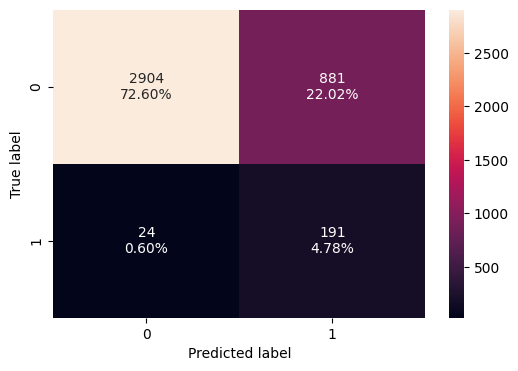

In [91]:
## lets plot the confusion matric table for oversampled dataset
confusion_matrix_sklearn(tuned_tree_clf_model_ov, X_valid, y_valid)

### Gradient Boosting with Random Search on Orginal Data

In [92]:
## define the model 
Model = GradientBoostingClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7], 
    "max_features":[0.5,0.7]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.5, 'n_estimators': 125, 'max_features': 0.7, 'learning_rate': 0.2} with CV score= 0.7497206703910614


In [93]:
tuned_gdb_model_og = GradientBoostingClassifier(
    n_estimators = 125, 
    learning_rate = 0.2, 
    subsample=0.5,
    max_features=0.7, 
   
)

tuned_gdb_model_og.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.2, max_features=0.7,
                           n_estimators=125, subsample=0.5)

In [94]:
## lets compute the metrics on the train set 
tuned_gdb_og_train_perf = model_performance_classification_sklearn(tuned_gdb_model_og, X_train, y_train)
tuned_gdb_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.990938,0.855866,0.97954,0.913536


In [95]:
## lets compute the metrics on the train set 
tuned_gdb_og_valid_perf = model_performance_classification_sklearn(tuned_gdb_model_og, X_valid, y_valid)
tuned_gdb_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.98425,0.781395,0.913043,0.842105


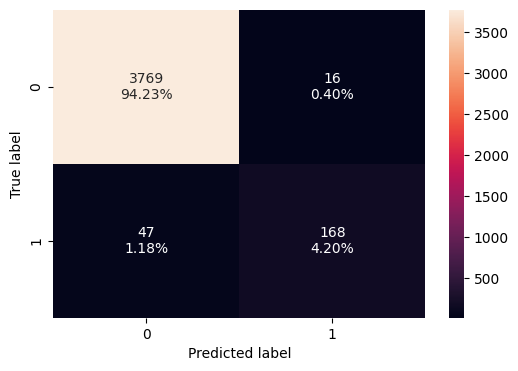

In [96]:
## lets plot the confusion matric table for original dataset
confusion_matrix_sklearn(tuned_gdb_model_og, X_valid, y_valid)

### Gradient Boosting with Random Search on UnderSampled Data

In [97]:
## define the model 
Model = GradientBoostingClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7], 
    "max_features":[0.5,0.7]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.5, 'n_estimators': 100, 'max_features': 0.5, 'learning_rate': 0.2} with CV score= 0.8960893854748603


In [98]:
tuned_gdb_model_un = GradientBoostingClassifier(
    n_estimators = 100, 
    learning_rate = 0.2, 
    subsample=0.5,
    max_features=0.5, 
   
)

tuned_gdb_model_un.fit(X_train_under, y_train_under)

GradientBoostingClassifier(learning_rate=0.2, max_features=0.5, subsample=0.5)

In [99]:
## lets compute the metrics on the train set 
tuned_gdb_un_train_perf = model_performance_classification_sklearn(tuned_gdb_model_un, X_train_under, y_train_under)
tuned_gdb_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.982682,0.969832,0.995413,0.982456


In [100]:
## lets compute the metrics on the train set 
tuned_gdb_un_valid_perf = model_performance_classification_sklearn(tuned_gdb_model_un, X_valid, y_valid)
tuned_gdb_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.9185,0.893023,0.387879,0.540845


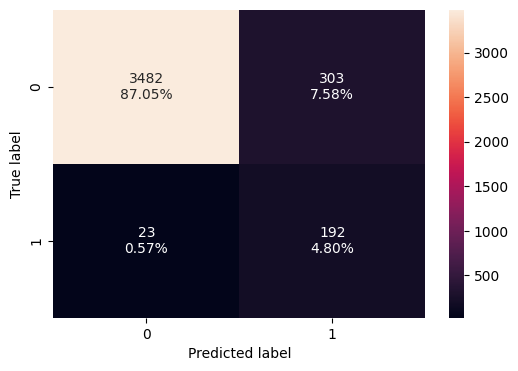

In [101]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_gdb_model_un, X_valid, y_valid)

### Gradient Boosting with Random Search on OverSampled Data

In [102]:
## define the model 
Model = GradientBoostingClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7], 
    "max_features":[0.5,0.7]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 1} with CV score= 0.9659053293611388


In [103]:
tuned_gdb_model_ov = GradientBoostingClassifier(
    n_estimators = 125, 
    learning_rate = 1, 
    subsample=0.7,
    max_features=0.5, 
   
)

tuned_gdb_model_ov.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=1, max_features=0.5, n_estimators=125,
                           subsample=0.7)

In [104]:
tuned_gdb_ov_train_perf = model_performance_classification_sklearn(tuned_gdb_model_ov, X_train_over, y_train_over)
tuned_gdb_ov_train_perf

,Accuracy,Recall,Precision,F1
0,0.993545,0.992982,0.994101,0.993542


In [105]:
## lets compute the metrics on the train set 
tuned_gdb_ov_valid_perf = model_performance_classification_sklearn(tuned_gdb_model_ov, X_valid, y_valid)
tuned_gdb_ov_valid_perf

,Accuracy,Recall,Precision,F1
0,0.966,0.837209,0.640569,0.725806


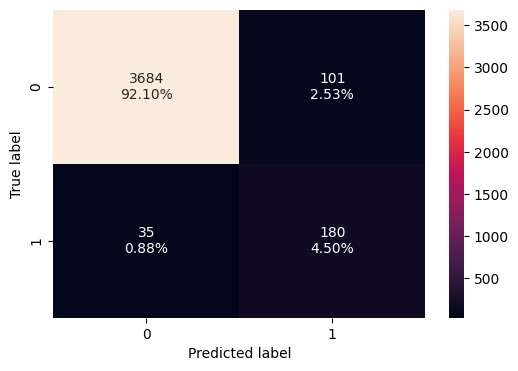

In [106]:
## lets plot the confusion matric table for oversampled dataset
confusion_matrix_sklearn(tuned_gdb_model_ov, X_valid, y_valid)

### Ada Boosting with Random Search on Orginal Data

In [107]:
## define the model 
Model = AdaBoostClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 200, 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score= 0.7675977653631285


In [108]:
tuned_ada_model_og = AdaBoostClassifier(
    n_estimators = 200, 
    learning_rate = 0.2, 
    estimator = DecisionTreeClassifier(max_depth=3, random_state=1)
)

tuned_ada_model_og.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=200)

In [109]:
tuned_ada_og_train_perf = model_performance_classification_sklearn(tuned_ada_model_og, X_train, y_train)
tuned_ada_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.998563,0.974302,1.0,0.986984


In [110]:
tuned_ada_og_valid_perf = model_performance_classification_sklearn(tuned_ada_model_og, X_valid, y_valid)
tuned_ada_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.98675,0.772093,0.976471,0.862338


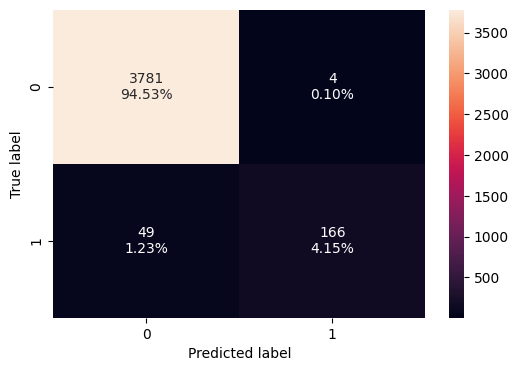

In [111]:
## lets plot the confusion matric table for original dataset
confusion_matrix_sklearn(tuned_ada_model_og, X_valid, y_valid)

### Ada Boosting with Random Search on UnderSampled Data

In [112]:
## define the model 
Model = AdaBoostClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 100, 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score= 0.8860335195530726


In [113]:
tuned_ada_model_un = AdaBoostClassifier(
    n_estimators = 100, 
    learning_rate = 0.2, 
    estimator = DecisionTreeClassifier(max_depth=3, random_state=1)
)

tuned_ada_model_un.fit(X_train_under, y_train_under)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=100)

In [114]:
tuned_ada_un_train_perf = model_performance_classification_sklearn(tuned_ada_model_un, X_train_under, y_train_under)
tuned_ada_un_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [115]:
tuned_ada_un_valid_perf = model_performance_classification_sklearn(tuned_ada_model_un, X_valid, y_valid)
tuned_ada_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.92275,0.883721,0.400844,0.551524


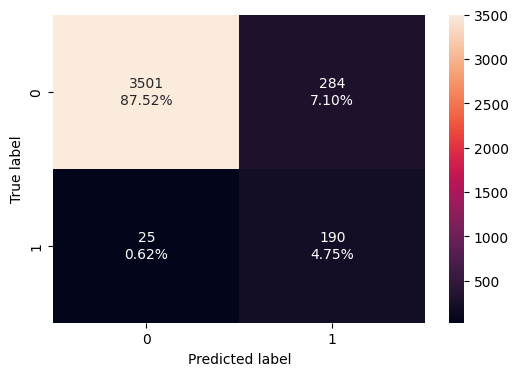

In [116]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_ada_model_un, X_valid, y_valid)

### Ada Boosting with Random Search on OverSampled Data

In [117]:
## define the model 
Model = AdaBoostClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV 
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 200, 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score= 0.9686858656074149


In [118]:
tuned_ada_model_ov = AdaBoostClassifier(
    n_estimators = 200, 
    learning_rate = 0.2, 
    estimator = DecisionTreeClassifier(max_depth=3, random_state=1)
)

tuned_ada_model_ov.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=200)

In [119]:
tuned_ada_ov_train_perf = model_performance_classification_sklearn(tuned_ada_model_ov, X_train_over, y_train_over)
tuned_ada_ov_train_perf

,Accuracy,Recall,Precision,F1
0,0.988613,0.982853,0.994307,0.988547


In [120]:
tuned_ada_ov_valid_perf = model_performance_classification_sklearn(tuned_ada_model_ov, X_valid, y_valid)
tuned_ada_ov_valid_perf

,Accuracy,Recall,Precision,F1
0,0.983,0.87907,0.818182,0.847534


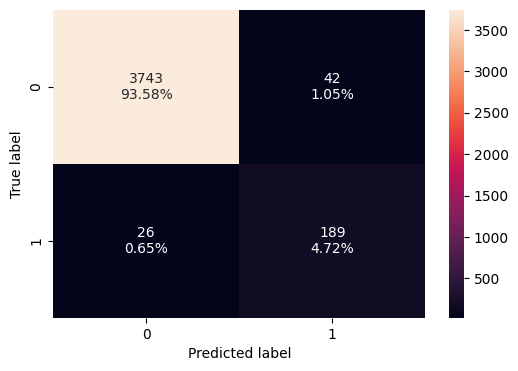

In [121]:
## lets plot the confusion matric table for oversampled dataset
confusion_matrix_sklearn(tuned_ada_model_ov, X_valid, y_valid)

### Bagging with Random Search on Orginal Data

In [122]:
## define the model 
Model = BaggingClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    'max_samples': [0.8,0.9,1], 
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 50, 'max_samples': 0.9, 'max_features': 0.9} with CV score= 0.7307262569832403


In [123]:
tuned_bagging_model_og = BaggingClassifier(
    n_estimators=50,
    max_samples=0.9,
    max_features=0.9,
    random_state=1
)

tuned_bagging_model_og.fit(X_train, y_train)

BaggingClassifier(max_features=0.9, max_samples=0.9, n_estimators=50,
                  random_state=1)

In [124]:
tuned_bg_og_train_perf = model_performance_classification_sklearn(tuned_gdb_model_og, X_train, y_train)
tuned_bg_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.990938,0.855866,0.97954,0.913536


In [125]:
tuned_bg_og_valid_perf = model_performance_classification_sklearn(tuned_gdb_model_og, X_valid, y_valid)
tuned_bg_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.98425,0.781395,0.913043,0.842105


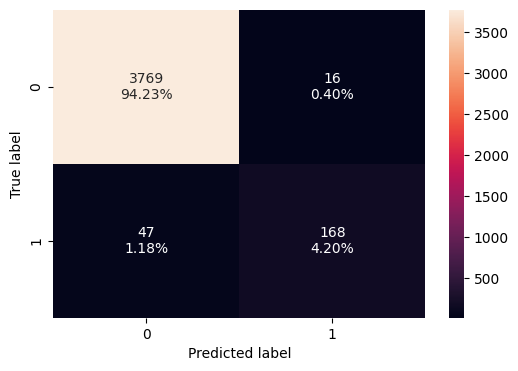

In [126]:
## lets plot the confusion matric table for original dataset
confusion_matrix_sklearn(tuned_gdb_model_og, X_valid, y_valid)

### Bagging with Random Search on UnderSampled Data

In [127]:
## define the model 
Model = BaggingClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    'max_samples': [0.8,0.9,1], 
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 70, 'max_samples': 0.8, 'max_features': 0.9} with CV score= 0.8960893854748603


In [128]:
tuned_bagging_model_un = BaggingClassifier(
   n_estimators=70,
    max_samples=0.8,
    max_features=0.9,
    random_state=1
)

tuned_bagging_model_un.fit(X_train_under, y_train_under)

BaggingClassifier(max_features=0.9, max_samples=0.8, n_estimators=70,
                  random_state=1)

In [129]:
tuned_bg_un_train_perf = model_performance_classification_sklearn(tuned_bagging_model_un, X_train_under, y_train_under)
tuned_bg_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.998883,0.997765,1.0,0.998881


In [130]:
tuned_bg_un_valid_perf = model_performance_classification_sklearn(tuned_bagging_model_un, X_valid, y_valid)
tuned_bg_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.9425,0.888372,0.481108,0.624183


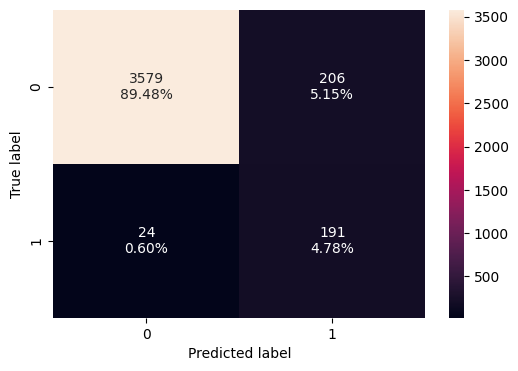

In [131]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_bagging_model_un, X_valid, y_valid)

### Bagging with Random Search on OverSampled Data

In [132]:
## define the model 
Model = BaggingClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid = {
    'max_samples': [0.8,0.9,1], 
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.8} with CV score= 0.982853359814631


In [133]:
tuned_bagging_model_ov = BaggingClassifier(
     n_estimators=70,
    max_samples=0.9,
    max_features=0.8,
    random_state=1
)

tuned_bagging_model_ov.fit(X_train_over, y_train_over)

BaggingClassifier(max_features=0.8, max_samples=0.9, n_estimators=70,
                  random_state=1)

In [134]:
tuned_bg_ov_train_perf = model_performance_classification_sklearn(tuned_bagging_model_ov, X_train_over, y_train_over)
tuned_bg_ov_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [135]:
tuned_bg_ov_valid_perf = model_performance_classification_sklearn(tuned_bagging_model_ov, X_valid, y_valid)
tuned_bg_ov_valid_perf

,Accuracy,Recall,Precision,F1
0,0.98675,0.855814,0.893204,0.874109


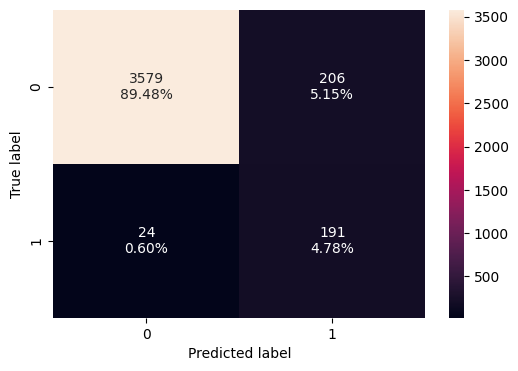

In [136]:
## lets plot the confusion matric table for oversampled dataset
confusion_matrix_sklearn(tuned_bagging_model_un, X_valid, y_valid)

### XGBoost with Random Search on Orginal Data

In [137]:
## define the model 
Model = XGBClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 250, 'learning_rate': 0.1, 'gamma': 5} with CV score= 0.8536312849162011


In [138]:
tuned_xgb_model_og = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    subsample=0.8, 
    scale_pos_weight=10, 
    n_estimators=250,
    learning_rate=0.1,
    gamma=5
)

tuned_xgb_model_og.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [139]:
tuned_xgb_og_train_perf = model_performance_classification_sklearn(tuned_xgb_model_og, X_train, y_train)
tuned_xgb_og_train_perf

,Accuracy,Recall,Precision,F1
0,0.9985,1.0,0.973885,0.98677


In [140]:
tuned_xgb_og_valid_perf = model_performance_classification_sklearn(tuned_xgb_model_og, X_valid, y_valid)
tuned_xgb_og_valid_perf

,Accuracy,Recall,Precision,F1
0,0.99075,0.874419,0.949495,0.910412


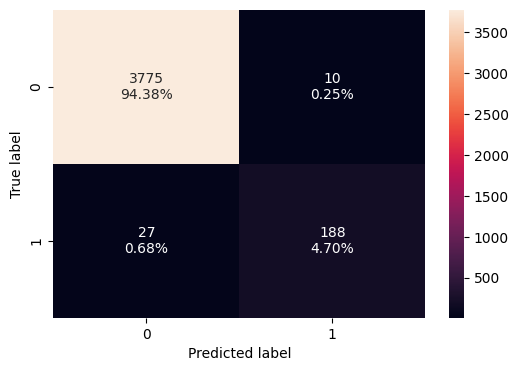

In [141]:
## lets plot the confusion matric table for original dataset
confusion_matrix_sklearn(tuned_xgb_model_og, X_valid, y_valid)

### XGBoost with Random Search on UnderSampled Data

In [142]:
## define the model 
Model = XGBClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.1, 'gamma': 5} with CV score= 0.9296089385474862


In [143]:
tuned_xgb_model_un = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    subsample=0.8, 
    scale_pos_weight=10, 
    n_estimators=200,
    learning_rate=0.1,
    gamma=5
)

tuned_xgb_model_un.fit(X_train_under, y_train_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [144]:
tuned_xgb_un_train_perf = model_performance_classification_sklearn(tuned_xgb_model_un, X_train_under, y_train_under)
tuned_xgb_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.978771,1.0,0.959271,0.979212


In [145]:
tuned_xgb_un_valid_perf = model_performance_classification_sklearn(tuned_xgb_model_un, X_valid, y_valid)
tuned_xgb_un_valid_perf

,Accuracy,Recall,Precision,F1
0,0.8305,0.92093,0.230501,0.368715


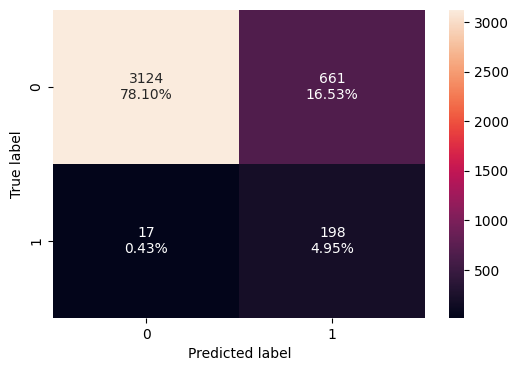

In [146]:
## lets plot the confusion matric table for undersampled dataset
confusion_matrix_sklearn(tuned_xgb_model_un, X_valid, y_valid)

### XGBoost with Random Search on OverSampled Data

In [147]:
## define the model 
Model = XGBClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 150, 'learning_rate': 0.1, 'gamma': 0} with CV score= 0.997153260509765


In [148]:
tuned_xgb_model_ov = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    subsample=0.9, 
    scale_pos_weight=10, 
    n_estimators=150,
    learning_rate=0.1,
    gamma=0
)

tuned_xgb_model_ov.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [149]:
tuned_xgb_ov_train_perf = model_performance_classification_sklearn(tuned_xgb_model_ov, X_train_over, y_train_over)
tuned_xgb_ov_train_perf

,Accuracy,Recall,Precision,F1
0,0.993413,1.0,0.986997,0.993456


In [150]:
tuned_xgb_ov_valid_perf = model_performance_classification_sklearn(tuned_xgb_model_ov, X_valid, y_valid)
tuned_xgb_ov_valid_perf

,Accuracy,Recall,Precision,F1
0,0.96875,0.906977,0.65,0.757282


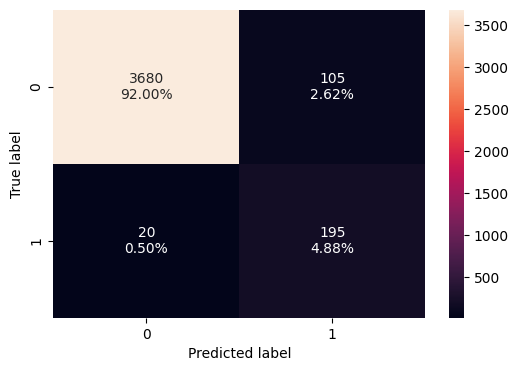

In [151]:
## lets plot the confusion matric table for overesampled dataset
confusion_matrix_sklearn(tuned_xgb_model_ov, X_valid, y_valid)

## Model Performance Comparison And Choosing The Final Model

In [152]:
## training performance comparison
models_train_comp_df = pd.concat([
    tuned_log_reg_og_train_perf.T,
    tuned_log_reg_un_train_perf.T,
    tuned_log_reg_ov_train_perf.T, 
        
    tuned_rf_clf_og_train_perf.T, 
    tuned_rf_clf_un_train_perf.T,
    tuned_rf_clf_ov_train_perf.T,
        
    tuned_tree_clf_og_train_perf.T,
    tuned_tree_clf_un_train_perf.T,
    tuned_tree_clf_ov_train_perf.T,
        
    tuned_gdb_og_train_perf.T,
    tuned_gdb_un_train_perf.T,
    tuned_gdb_ov_train_perf.T, 
        
    tuned_ada_og_train_perf.T,
    tuned_ada_un_train_perf.T,
    tuned_ada_ov_train_perf.T,
        
    tuned_bg_og_train_perf.T,
    tuned_bg_un_train_perf.T,
    tuned_bg_ov_train_perf.T,
        
    tuned_xgb_og_train_perf.T,
    tuned_xgb_un_train_perf.T,
    tuned_xgb_ov_train_perf.T
    ],
    axis=1,

)

## 
models_train_comp_df.columns = [
    'Logistic Regression Tuned on Original Data',
    'Logistic Regression Tuned on Undersampled Data',
    'Logistic Regression Tuned on Oversampled Data',
    
    'Random Forest Tuned on Original Data',
    'Random Forest Tuned on Undersampled Data',
    'Random Forest Tuned on Oversampled Data',
    
    'Decison Tree Tuned on Original Data',
    'Decison Tree Tuned on Undersampled Data',
    'Decison Tree Tuned on Oversampled Data',
    
    'Gradient Boosting Tuned on Original Data',
    'Gradient Boosting Tuned on Undersampled Data',
    'Gradient Boosting Tuned on Oversampled Data',
    
    'AdaBoost Tuned on Original Data',
    'AdaBoost Tuned on Undersampled Data',
    'AdaBoost Tuned on Oversampled Data',
    
    'Bagging Tuned on Original Data',
    'Bagging Tuned on Undersampled Data',
    'Bagging Tuned on Oversampled Data',
    
    'XGBoost Tuned on Original Data',
    'XGBoost Tuned on Undersampled Data',
    'XGBoost Tuned on Oversampled Data'  
    
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression Tuned on Original Data,Logistic Regression Tuned on Undersampled Data,Logistic Regression Tuned on Oversampled Data,Random Forest Tuned on Original Data,Random Forest Tuned on Undersampled Data,Random Forest Tuned on Oversampled Data,Decison Tree Tuned on Original Data,Decison Tree Tuned on Undersampled Data,Decison Tree Tuned on Oversampled Data,Gradient Boosting Tuned on Original Data,...,Gradient Boosting Tuned on Oversampled Data,AdaBoost Tuned on Original Data,AdaBoost Tuned on Undersampled Data,AdaBoost Tuned on Oversampled Data,Bagging Tuned on Original Data,Bagging Tuned on Undersampled Data,Bagging Tuned on Oversampled Data,XGBoost Tuned on Original Data,XGBoost Tuned on Undersampled Data,XGBoost Tuned on Oversampled Data
Accuracy,0.965500,0.860894,0.874843,0.995000,0.964246,0.999702,0.972313,0.904000,0.841708,0.990938,...,0.993545,0.998563,1.0,0.988613,0.990938,0.998883,1.0,0.998500,0.978771,0.993413
Recall,0.472626,0.856983,0.877193,0.911732,0.935196,0.999603,0.598883,0.850279,0.909633,0.855866,...,0.992982,0.974302,1.0,0.982853,0.855866,0.997765,1.0,1.000000,1.000000,1.000000
Precision,0.840954,0.863739,0.873089,0.998776,0.992883,0.999801,0.864516,0.351826,0.800839,0.979540,...,0.994101,1.000000,1.0,0.994307,0.979540,1.000000,1.0,0.973885,0.959271,0.986997
F1,0.605150,0.860348,0.875136,0.953271,0.963176,0.999702,0.707591,0.497711,0.851776,0.913536,...,0.993542,0.986984,1.0,0.988547,0.913536,0.998881,1.0,0.986770,0.979212,0.993456


In [153]:
#models_train_comp_df > 'train_model_result.txt'

In [154]:
## validation performance comparism
models_val_comp_df = pd.concat(

[
    tuned_log_reg_og_valid_perf.T,
    tuned_log_reg_un_valid_perf.T,
    tuned_log_reg_ov_valid_perf.T, 
    tuned_rf_clf_og_valid_perf.T, 
    tuned_rf_clf_un_valid_perf.T,
    tuned_rf_clf_over_valid_perf.T,
    tuned_tree_clf_og_valid_perf.T,
    tuned_tree_clf_un_valid_perf.T,
    tuned_tree_clf_ov_valid_perf.T,
    tuned_gdb_og_valid_perf.T,
    tuned_gdb_un_valid_perf.T,
    tuned_gdb_ov_valid_perf.T, 
    tuned_ada_og_valid_perf.T,
    tuned_ada_un_valid_perf.T,
    tuned_ada_ov_valid_perf.T,
    tuned_bg_og_valid_perf.T,
    tuned_bg_un_valid_perf.T,
    tuned_bg_ov_valid_perf.T,
    tuned_xgb_og_valid_perf.T,
    tuned_xgb_un_valid_perf.T,
    tuned_xgb_ov_valid_perf.T
],
    axis=1,
)

models_val_comp_df.columns = [
    'Logistic Regression Tuned on Original Data',
    'Logistic Regression Tuned on Undersampled Data',
    'Logistic Regression Tuned on Oversampled Data',
    'Random Forest Tuned on Original Data',
    'Random Forest Tuned on Undersampled Data',
    'Random Forest Tuned on Oversampled Data',
    'Decison Tree Tuned on Original Data',
    'Decison Tree Tuned on Undersampled Data',
    'Decison Tree Tuned on Oversampled Data',
    'Gradient Boosting Tuned on Original Data',
    'Gradient Boosting Tuned on Undersampled Data',
    'Gradient Boosting Tuned on Oversampled Data',
    'AdaBoost Tuned on Original Data',
    'AdaBoost Tuned on Undersampled Data',
    'AdaBoost Tuned on Oversampled Data',
    'Bagging Tuned on Original Data',
    'Bagging Tuned on Undersampled Data',
    'Bagging Tuned on Oversampled Data',
    'XGBoost Tuned on Original Data',
    'XGBoost Tuned on Undersampled Data',
    'XGBoost Tuned on Oversampled Data'    
    
]

print("Validation performance comparison: ")

models_val_comp_df

Validation performance comparison: 


,Logistic Regression Tuned on Original Data,Logistic Regression Tuned on Undersampled Data,Logistic Regression Tuned on Oversampled Data,Random Forest Tuned on Original Data,Random Forest Tuned on Undersampled Data,Random Forest Tuned on Oversampled Data,Decison Tree Tuned on Original Data,Decison Tree Tuned on Undersampled Data,Decison Tree Tuned on Oversampled Data,Gradient Boosting Tuned on Original Data,...,Gradient Boosting Tuned on Oversampled Data,AdaBoost Tuned on Original Data,AdaBoost Tuned on Undersampled Data,AdaBoost Tuned on Oversampled Data,Bagging Tuned on Original Data,Bagging Tuned on Undersampled Data,Bagging Tuned on Oversampled Data,XGBoost Tuned on Original Data,XGBoost Tuned on Undersampled Data,XGBoost Tuned on Oversampled Data
Accuracy,0.972000,0.858500,0.869000,0.986500,0.946000,0.989250,0.974750,0.891500,0.773750,0.984250,...,0.966000,0.986750,0.922750,0.983000,0.984250,0.942500,0.986750,0.990750,0.830500,0.968750
Recall,0.553488,0.883721,0.874419,0.748837,0.902326,0.860465,0.618605,0.809302,0.888372,0.781395,...,0.837209,0.772093,0.883721,0.879070,0.781395,0.888372,0.855814,0.874419,0.920930,0.906977
Precision,0.881481,0.259918,0.274453,1.000000,0.498715,0.934343,0.875000,0.306878,0.178172,0.913043,...,0.640569,0.976471,0.400844,0.818182,0.913043,0.481108,0.893204,0.949495,0.230501,0.650000
F1,0.680000,0.401691,0.417778,0.856383,0.642384,0.895884,0.724796,0.445013,0.296814,0.842105,...,0.725806,0.862338,0.551524,0.847534,0.842105,0.624183,0.874109,0.910412,0.368715,0.757282


### Observations: 
The XGBoost alg on undersampled and oversampled Data return the best recall value of 92% and 91% respectively. 
To improve the performance of the model, lets use the two techniques to train the model on the entire training dataset.

## Training of Final Model

In [155]:
## lets select the final training features and target dataframe 
X_train_final = scaled_X_train
y_train = df_train['Target']

## lets convert the features dataframe to numpy array
X_train = X_train_final.values

In [156]:
## lets perform synthetic minority over sampling technique 
sm = RandomUnderSampler(sampling_strategy=1,  random_state=11)
X_train_under, y_train_under = sm.fit_resample(X_train, y_train)

### XGBoost with Random Search on UnderSampled Data

In [157]:
## define the model 
Model = XGBClassifier(random_state=1)

## parameter grid to pass in RandomSearchCV
param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}
## calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid ,n_iter=50, n_jobs=-1, scoring=scorer, cv=5, random_state=1)

## fitting parameters to RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print(f'Best parameters are: {randomized_cv.best_params_} with CV score= {randomized_cv.best_score_}')

Best parameters are: {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.2, 'gamma': 5} with CV score= 0.927927927927928


In [158]:
tuned_xgb_model_un = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    subsample=0.9, 
    scale_pos_weight=10, 
    n_estimators=200,
    learning_rate=0.2,
    gamma=5
)

tuned_xgb_model_un.fit(X_train_under, y_train_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [159]:
tuned_xgb_un_train_perf = model_performance_classification_sklearn(tuned_xgb_model_un, X_train_under, y_train_under)
tuned_xgb_un_train_perf

,Accuracy,Recall,Precision,F1
0,0.98018,1.0,0.961872,0.980565


In [160]:
tuned_xgb_un_test_perf = model_performance_classification_sklearn(tuned_xgb_model_un, X_test, y_test)
tuned_xgb_un_test_perf

,Accuracy,Recall,Precision,F1
0,0.8266,0.897163,0.231897,0.368536


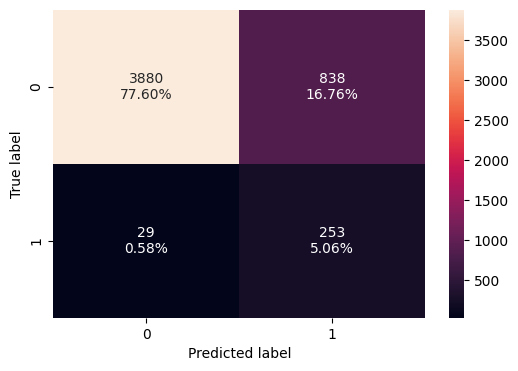

In [161]:
## lets plot the confusion matrix
confusion_matrix_sklearn(tuned_xgb_model_un, X_test, y_test)

Observations 
- The number of correct prediction for True Negative and True positive were 77.60% and 5.06% respectively,
- The number of wrong prediction for False positive and False Negative were 16.76% and 0.58 % respectively.

### Feature Importance
Feature importance helps to assign scores to input features based on their relevance or contribution to the predictive model. Understanding feature importance helps in selecting the most significant features, improving model performance, and providing insights into the data. 

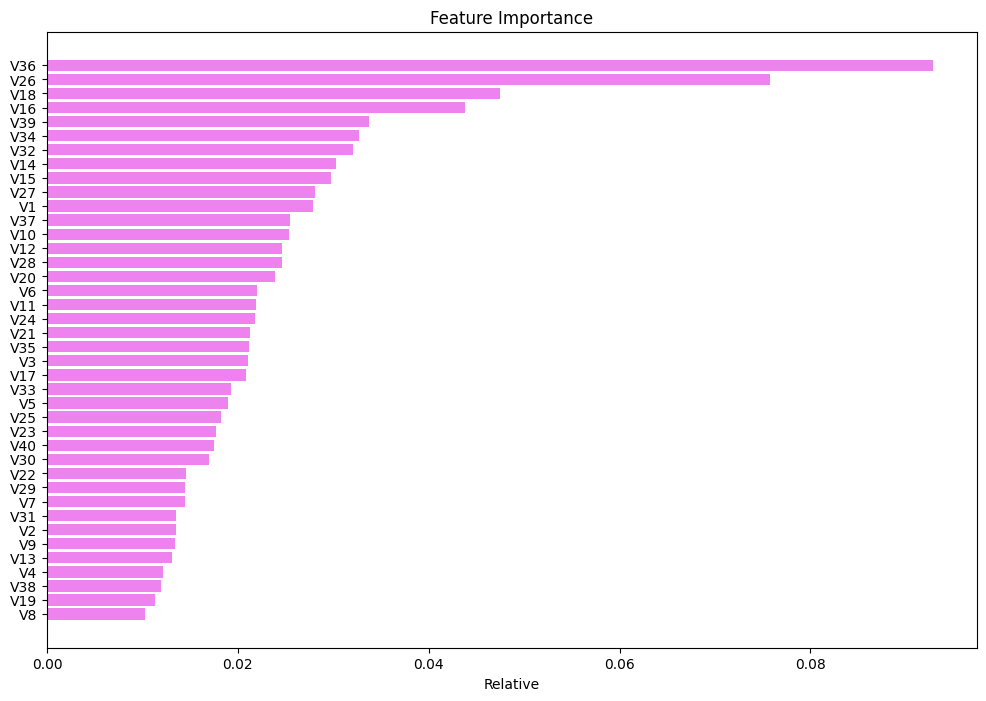

In [162]:
feature_names = X_train_final.columns
importance_features = tuned_xgb_model_un.feature_importances_
indices = np.argsort(importance_features)


plt.figure(figsize=(12, 8))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importance_features[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative")
plt.show()

### Observations
- The above diagram gives us an understanding of which features played an important role in the build-up process
- Features V36, V26, V18, and V16 should be given important consideration